In [1]:
# Standard imports
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from typing import Dict, Tuple, Optional, Any, List
from dataclasses import dataclass
from collections import defaultdict
import os
import glob
# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
from moe_flashattn_4_core import (
    # Data preparation
    prepare_data_once,
    PreparedData,
    
    # Model classes
    BaselineTransformer,
    FlashAttentionTransformer,
    FlashMoETransformer,
    DataParallelWrapper,
    
    # Config classes
    BaseConfig,
    FlashAttentionConfig,
    MoEConfig,
    
    # Data classes
    ClinicalDataset,
    PreparedData,
    create_collate_fn,
    
    # Utilities
    load_trained_model,
    _model_has_moe,
)

### Raw codes predict IP risk

In [4]:
import google.auth
from google.auth import impersonated_credentials
from google.cloud import bigquery
client = bigquery.Client()
credentials, project= google.auth.default()

In [ ]:
# CREATE OR REPLACE TABLE `edp-prod-storage.edp_ent_sdoheir_cns.a964286_combined_cp_10pct_sample_ip_outcomes_for_code_freq_analysis`
# OPTIONS (
#     labels = [("owner", "zhaopeng_xing_cvshealth_com"), ("cost_center", "13070")],
#     description = "IP outcomes for combined LOB training sample for code-IP association analysis",
#     expiration_timestamp = TIMESTAMP_ADD(CURRENT_TIMESTAMP(), INTERVAL 180 DAY)
# ) AS

# WITH training_members AS (
#     -- Get unique members from training data
#     SELECT DISTINCT
#         individual_id,
#         lob,
#         index_dt
#     FROM `edp-prod-storage.edp_ent_sdoheir_cns.a834793_Combined_All_LOB_o3_train_10pct_sample`
# ),

# commercial_outcomes AS (
#     -- Commercial IP outcomes (ip6)
#     SELECT 
#         individual_id,
#         index_dt,
#         ip6 AS ip_flag
#     FROM `edp-prod-storage.edp_ent_sdoheir_cns.a834793_Commercial_final_dataset_4_te_experiment`
#     WHERE mon_6_include = 1
# )

# -- Join training members with appropriate outcome table based on LOB
# SELECT 
#     t.individual_id,
#     t.lob,
#     t.index_dt,
#     COALESCE(c.ip_flag, 0) AS ip_flag
# FROM training_members t
# LEFT JOIN commercial_outcomes c
#     ON t.individual_id = c.individual_id 
#     AND t.index_dt = c.index_dt 
#     AND t.lob = 'Commercial'
# ;

In [12]:
# ============================================================
# CODE-TIER IP RISK ASSOCIATION ANALYSIS
# Question: Are rare/tail codes more predictive of IP risk?
# ============================================================

import numpy as np
import pandas as pd
from collections import Counter, defaultdict
from typing import Dict, List, Tuple, Optional
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# DATA PARSING FUNCTIONS
# ============================================================

def parse_target_codes(target_str: str) -> set:
    """
    Parse target string to get unique codes.
    Format: "972*927,928,930*972*908*" where * separates days, , separates codes
    
    Returns: Set of unique code integers
    """
    if pd.isna(target_str) or target_str == '':
        return set()
    
    codes = set()
    days = target_str.strip('*').split('*')
    
    for day in days:
        if day:
            day_codes = day.split(',')
            for code in day_codes:
                code = code.strip()
                if code and code.isdigit():
                    codes.add(int(code))
    
    return codes


def extract_member_codes(train_df: pd.DataFrame) -> pd.DataFrame:
    """
    Extract unique codes per member from training data.
    
    Returns:
        DataFrame with columns: individual_id, unique_codes (set), total_code_count
    """
    print("Extracting member codes...")
    
    results = []
    for idx, row in train_df.iterrows():
        if idx > 0 and idx % 100000 == 0:
            print(f"  Processed {idx:,}/{len(train_df):,}")
        
        codes = parse_target_codes(row['target'])
        results.append({
            'individual_id': row['individual_id'],
            'unique_codes': codes,
            'total_code_count': len(codes)
        })
    
    df_codes = pd.DataFrame(results)
    print(f"  Extracted codes for {len(df_codes):,} members")
    return df_codes


# ============================================================
# CODE FREQUENCY AND TIER ASSIGNMENT
# ============================================================

def compute_code_frequencies(df_codes: pd.DataFrame) -> Counter:
    """Compute frequency of each code across all members."""
    print("Computing code frequencies...")
    code_counts = Counter()
    
    for codes in df_codes['unique_codes']:
        code_counts.update(codes)
    
    print(f"  Found {len(code_counts):,} unique codes")
    return code_counts


def assign_code_tiers(
    code_frequencies: Counter,
    percentile_boundaries: Tuple[float, float, float] = (20, 50, 80)
) -> Dict[int, str]:
    """
    Assign each code to a tier based on frequency percentiles.
    
    Returns:
        Dict mapping code -> tier name ('common', 'medium', 'rare', 'tail')
    """
    freqs = np.array(list(code_frequencies.values()))
    percentiles = np.percentile(freqs, list(percentile_boundaries))
    
    code_to_tier = {}
    for code, freq in code_frequencies.items():
        if freq > percentiles[2]:
            code_to_tier[code] = 'common'
        elif freq > percentiles[1]:
            code_to_tier[code] = 'medium'
        elif freq > percentiles[0]:
            code_to_tier[code] = 'rare'
        else:
            code_to_tier[code] = 'tail'
    
    # Print tier distribution
    tier_counts = Counter(code_to_tier.values())
    print(f"\nTier assignment (percentiles: {percentile_boundaries}):")
    print(f"  Common: freq > {percentiles[2]:.0f} ({tier_counts['common']:,} codes)")
    print(f"  Medium: {percentiles[1]:.0f} < freq ≤ {percentiles[2]:.0f} ({tier_counts['medium']:,} codes)")
    print(f"  Rare:   {percentiles[0]:.0f} < freq ≤ {percentiles[1]:.0f} ({tier_counts['rare']:,} codes)")
    print(f"  Tail:   freq ≤ {percentiles[0]:.0f} ({tier_counts['tail']:,} codes)")
    
    return code_to_tier


# ============================================================
# ODDS RATIO COMPUTATION
# ============================================================

def compute_odds_ratio(
    a: int, b: int, c: int, d: int, 
    pseudocount: float = 0.5
) -> Tuple[float, float, float]:
    """
    Compute odds ratio and 95% CI from 2x2 contingency table.
    
    Table:        IP=1    IP=0
    code=1:        a       b
    code=0:        c       d
    
    Returns:
        (OR, CI_lower, CI_upper)
    """
    # Add pseudocount for stability
    a, b, c, d = a + pseudocount, b + pseudocount, c + pseudocount, d + pseudocount
    
    # Odds ratio
    OR = (a * d) / (b * c)
    
    # Standard error of log(OR)
    se_log_or = np.sqrt(1/a + 1/b + 1/c + 1/d)
    
    # 95% CI
    log_or = np.log(OR)
    ci_lower = np.exp(log_or - 1.96 * se_log_or)
    ci_upper = np.exp(log_or + 1.96 * se_log_or)
    
    return OR, ci_lower, ci_upper


def compute_code_ip_associations(
    df_analysis: pd.DataFrame,
    code_frequencies: Counter,
    code_to_tier: Dict[int, str],
    min_occurrences: int = 50
) -> pd.DataFrame:
    """
    Compute OR for each code's association with IP.
    
    Args:
        df_analysis: DataFrame with 'unique_codes', 'ip6', 'total_code_count'
        code_frequencies: Counter of code frequencies
        code_to_tier: Dict mapping code to tier
        min_occurrences: Minimum code occurrences to include (for stability)
    
    Returns:
        DataFrame with code-level OR statistics
    """
    print(f"\nComputing OR for codes with ≥{min_occurrences} occurrences...")
    
    # Overall IP rate
    n_total = len(df_analysis)
    n_ip = df_analysis['ip6'].sum()
    n_no_ip = n_total - n_ip
    
    print(f"  Total members: {n_total:,}")
    print(f"  IP+: {n_ip:,} ({n_ip/n_total:.2%})")
    print(f"  IP-: {n_no_ip:,}")
    
    # Pre-compute IP status arrays for speed
    ip_positive = df_analysis[df_analysis['ip6'] == 1]['unique_codes'].tolist()
    ip_negative = df_analysis[df_analysis['ip6'] == 0]['unique_codes'].tolist()
    
    # Count code occurrences in IP+ and IP- groups
    code_in_ip_pos = Counter()
    code_in_ip_neg = Counter()
    
    for codes in ip_positive:
        code_in_ip_pos.update(codes)
    for codes in ip_negative:
        code_in_ip_neg.update(codes)
    
    # Compute OR for each code
    results = []
    codes_to_analyze = [c for c, freq in code_frequencies.items() if freq >= min_occurrences]
    
    print(f"  Analyzing {len(codes_to_analyze):,} codes (of {len(code_frequencies):,} total)")
    
    for code in codes_to_analyze:
        # Contingency table
        a = code_in_ip_pos.get(code, 0)  # code=1, IP=1
        c = n_ip - a                      # code=0, IP=1
        b = code_in_ip_neg.get(code, 0)  # code=1, IP=0
        d = n_no_ip - b                   # code=0, IP=0
        
        # Compute OR
        OR, ci_lower, ci_upper = compute_odds_ratio(a, b, c, d)
        
        results.append({
            'code': code,
            'tier': code_to_tier.get(code, 'unknown'),
            'frequency': code_frequencies[code],
            'n_ip_pos': a,
            'n_ip_neg': b,
            'odds_ratio': OR,
            'or_ci_lower': ci_lower,
            'or_ci_upper': ci_upper,
            'log_or': np.log(OR),
            'significant': ci_lower > 1.0 or ci_upper < 1.0  # CI doesn't cross 1
        })
    
    df_or = pd.DataFrame(results)
    print(f"  Computed OR for {len(df_or):,} codes")
    
    return df_or


# ============================================================
# TIER-LEVEL AGGREGATION
# ============================================================

def aggregate_by_tier(df_or: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregate OR statistics by tier.
    """
    print("\n" + "="*70)
    print("TIER-LEVEL AGGREGATION")
    print("="*70)
    
    tier_order = ['common', 'medium', 'rare', 'tail']
    
    results = []
    for tier in tier_order:
        tier_data = df_or[df_or['tier'] == tier]
        
        if len(tier_data) == 0:
            continue
        
        n_codes = len(tier_data)
        median_or = tier_data['odds_ratio'].median()
        mean_log_or = tier_data['log_or'].mean()
        std_log_or = tier_data['log_or'].std()
        pct_or_above_1_5 = (tier_data['odds_ratio'] > 1.5).mean() * 100
        pct_or_above_2 = (tier_data['odds_ratio'] > 2.0).mean() * 100
        pct_protective = (tier_data['odds_ratio'] < 0.67).mean() * 100
        pct_significant = tier_data['significant'].mean() * 100
        
        results.append({
            'tier': tier,
            'n_codes': n_codes,
            'median_or': median_or,
            'mean_log_or': mean_log_or,
            'std_log_or': std_log_or,
            'pct_or_above_1.5': pct_or_above_1_5,
            'pct_or_above_2.0': pct_or_above_2,
            'pct_protective': pct_protective,
            'pct_significant': pct_significant
        })
    
    df_summary = pd.DataFrame(results)
    
    # Print summary
    print(f"\n{'Tier':<10} {'N Codes':>10} {'Median OR':>12} {'% OR>1.5':>10} {'% OR>2.0':>10} {'% Protective':>14}")
    print("-" * 70)
    for _, row in df_summary.iterrows():
        print(f"{row['tier']:<10} {row['n_codes']:>10,} {row['median_or']:>12.2f} "
              f"{row['pct_or_above_1.5']:>9.1f}% {row['pct_or_above_2.0']:>9.1f}% "
              f"{row['pct_protective']:>13.1f}%")
    
    return df_summary


def print_top_codes_by_tier(df_or: pd.DataFrame, n_top: int = 10):
    """Print top OR codes for each tier."""
    print("\n" + "="*70)
    print(f"TOP {n_top} CODES BY ODDS RATIO (PER TIER)")
    print("="*70)
    
    tier_order = ['common', 'medium', 'rare', 'tail']
    
    for tier in tier_order:
        tier_data = df_or[df_or['tier'] == tier].nlargest(n_top, 'odds_ratio')
        
        print(f"\n{tier.upper()} TIER (Top {n_top}):")
        print(f"  {'Code':>8} {'Freq':>8} {'OR':>8} {'95% CI':>20} {'IP+':>8} {'IP-':>8}")
        print("  " + "-" * 60)
        
        for _, row in tier_data.iterrows():
            ci_str = f"[{row['or_ci_lower']:.2f}, {row['or_ci_upper']:.2f}]"
            print(f"  {row['code']:>8} {row['frequency']:>8,} {row['odds_ratio']:>8.2f} "
                  f"{ci_str:>20} {row['n_ip_pos']:>8,} {row['n_ip_neg']:>8,}")


In [24]:
print("Loading training data (codes)...")
input_sql = """
SELECT *
FROM `edp-prod-storage.edp_ent_sdoheir_cns.a834793_Combined_All_LOB_o3_train_10pct_sample`
"""
# train_df = client.query(input_sql).to_dataframe()
print(f"  Loaded {len(train_df):,} training records")

print("Loading outcome data (IP6)...")
feature_sql = """
SELECT *
FROM `edp-prod-storage.edp_ent_sdoheir_cns.a964286_combined_cp_10pct_sample_ip_outcomes_for_code_freq_analysis`
"""
outcome_df = client.query(feature_sql).to_dataframe()

Loading training data (codes)...
  Loaded 1,767,053 training records
Loading outcome data (IP6)...


In [18]:
train_df.individual_id

0              292760898495
1               90107661620
2           284967483619678
3            69904613294594
4               88523213792
                 ...       
1767048            15743694
1767049          8576478538
1767050          3691461032
1767051    2153605917540195
1767052    1844315492475552
Name: individual_id, Length: 1767053, dtype: Int64

In [30]:
outcome_df.ip6.value_counts()

ip6
0    1760273
1       6780
Name: count, dtype: Int64

In [26]:
# df_codes = extract_member_codes(train_df)

# # Step 3: Compute code frequencies
# code_frequencies = compute_code_frequencies(df_codes)

# Step 4: Assign tiers
code_to_tier = assign_code_tiers(code_frequencies, percentile_boundaries = (20, 50, 80))

# Step 5: Join with outcomes
print("\nJoining with outcomes data...")
df_analysis = df_codes.merge(
    outcome_df[['individual_id', 'ip6']], 
    on='individual_id', 
    how='inner'
)
print(f"  Matched {len(df_analysis):,} members (of {len(df_codes):,} in training)")
print(f"  IP rate in matched: {df_analysis['ip6'].mean():.2%}")

# Step 6: Compute OR for each code
df_or = compute_code_ip_associations(
    df_analysis, 
    code_frequencies, 
    code_to_tier,
    min_occurrences=50
)

# Step 7: Aggregate by tier
df_summary = aggregate_by_tier(df_or)

# Step 8: Show top codes
print_top_codes_by_tier(df_or, n_top=10)

# Step 9: Statistical comparison of tiers
print("\n" + "="*70)
print("STATISTICAL COMPARISON: Are tier OR distributions different?")
print("="*70)

tier_order = ['common', 'medium', 'rare', 'tail']
for i, tier1 in enumerate(tier_order):
    for tier2 in tier_order[i+1:]:
        data1 = df_or[df_or['tier'] == tier1]['log_or']
        data2 = df_or[df_or['tier'] == tier2]['log_or']

        if len(data1) > 5 and len(data2) > 5:
            stat, pval = stats.mannwhitneyu(data1, data2, alternative='two-sided')
            sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else ""
            print(f"  {tier1} vs {tier2}: Mann-Whitney p={pval:.4f} {sig}")


Tier assignment (percentiles: (20, 50, 80)):
  Common: freq > 6240 (1,148 codes)
  Medium: 277 < freq ≤ 6240 (1,722 codes)
  Rare:   16 < freq ≤ 277 (1,709 codes)
  Tail:   freq ≤ 16 (1,162 codes)

Joining with outcomes data...
  Matched 1,779,539 members (of 1,767,053 in training)
  IP rate in matched: 0.38%

Computing OR for codes with ≥50 occurrences...
  Total members: 1,779,539
  IP+: 6,833 (0.38%)
  IP-: 1,772,706
  Analyzing 3,936 codes (of 5,741 total)
  Computed OR for 3,936 codes

TIER-LEVEL AGGREGATION

Tier          N Codes    Median OR   % OR>1.5   % OR>2.0   % Protective
----------------------------------------------------------------------
common          1,148         1.46      47.3%      26.7%           7.8%
medium          1,722         1.76      57.0%      44.7%          17.3%
rare            1,066         2.42      72.0%      58.8%           5.9%

TOP 10 CODES BY ODDS RATIO (PER TIER)

COMMON TIER (Top 10):
      Code     Freq       OR               95% CI      IP+

In [27]:
common_median = df_summary[df_summary['tier'] == 'common']['median_or'].values[0]
tail_median = df_summary[df_summary['tier'] == 'tail']['median_or'].values[0] if 'tail' in df_summary['tier'].values else None

if tail_median:
    if tail_median > common_median * 1.2:
        print(f"\n✅ TAIL codes have HIGHER median OR ({tail_median:.2f}) than COMMON ({common_median:.2f})")
        print("   → Rare/tail codes contain concentrated predictive signal for IP risk")
        print("   → Improving rare code learning MAY improve downstream IP prediction")
    elif tail_median < common_median * 0.8:
        print(f"\n⚠️ TAIL codes have LOWER median OR ({tail_median:.2f}) than COMMON ({common_median:.2f})")
        print("   → Rare/tail codes are LESS predictive of IP risk on average")
        print("   → Focus on common code learning may be more impactful")
    else:
        print(f"\n📊 TAIL codes have SIMILAR median OR ({tail_median:.2f}) to COMMON ({common_median:.2f})")
        print("   → Predictive signal is distributed similarly across frequency tiers")

In [28]:
common_median

1.4638922461935515

In [29]:
tail_median

### PER-CODE LOGIT/EMBEDDING DIAGNOSTIC ANALYSIS

In [3]:
# ============================================================
# PRIORITY 1: PER-CODE LOGIT/EMBEDDING DIAGNOSTIC ANALYSIS
# ============================================================
# Purpose: Diagnose if rare/tail codes have:
#   - Collapsed embeddings (norms ≈ 0)
#   - Weak but non-zero logits
#   - Oscillating/unstable logits
# 
# This is a ZERO-COST diagnostic that runs on existing checkpoints.
# Run BEFORE implementing any training interventions.
# ============================================================
# ============================================================
# PER-CODE DIAGNOSTIC ANALYZER
# ============================================================

@dataclass
class TierDiagnosticResult:
    """Container for diagnostic results per tier."""
    tier_name: str
    num_codes: int
    # Embedding analysis
    embedding_norm_mean: float
    embedding_norm_std: float
    embedding_norm_min: float
    embedding_norm_max: float
    # Logit analysis (when y=1)
    logit_when_positive_mean: float
    logit_when_positive_std: float
    logit_when_positive_min: float
    logit_when_positive_max: float
    # Logit analysis (when y=0)  
    logit_when_negative_mean: float
    logit_when_negative_std: float
    # Margin analysis
    margin_vs_threshold: float
    positive_rate_above_threshold: float
    
    def __repr__(self):
        return (f"TierDiagnostic({self.tier_name}): "
                f"emb_norm={self.embedding_norm_mean:.4f}±{self.embedding_norm_std:.4f}, "
                f"logit_pos={self.logit_when_positive_mean:.4f}±{self.logit_when_positive_std:.4f}, "
                f"margin={self.margin_vs_threshold:.4f}, "
                f"above_thresh={self.positive_rate_above_threshold:.2%}")


class PerCodeDiagnosticAnalyzer:
    """
    Diagnostic analyzer for per-code logit and embedding analysis.
    
    Works with all model types from moe_flashattn_4_core.py:
    - BaselineTransformer
    - FlashAttentionTransformer  
    - FlashMoETransformer
    
    Usage:
        # Load model checkpoint
        model = load_trained_model(
            model_path='path/to/checkpoint.pt',
            model_class=FlashAttentionTransformer,
            config=config,
            device=device
        )
        
        # Create analyzer
        analyzer = PerCodeDiagnosticAnalyzer(
            code_frequencies=prepared_data.code_frequencies,
            device=device
        )
        
        # Run diagnostic on validation data
        results = analyzer.run_full_diagnostic(
            model=model,
            dataloader=val_loader,
            config=config,
            num_batches=50
        )
        
        # Print diagnosis
        analyzer.print_diagnosis(results)
        
        # Plot distributions
        analyzer.plot_distributions(results)
    """
    
    def __init__(
        self,
        code_frequencies: np.ndarray,
        device: torch.device,
        percentile_boundaries: Tuple[float, float, float] = (20, 50, 80)
    ):
        self.device = device
        self.num_codes = len(code_frequencies)
        self.code_frequencies = code_frequencies
        
        # Build tier indices (same logic as GradientTierAnalyzer in training)
        freq_nz = code_frequencies[code_frequencies > 0]
        if len(freq_nz) == 0:
            raise ValueError("No non-zero frequencies found")
        
        percentiles = np.percentile(freq_nz, list(percentile_boundaries))
        
        # Create tier masks
        self.tier_indices = {}
        self.tier_masks = {}
        
        # Common: above 80th percentile
        common_mask = code_frequencies > percentiles[2]
        self.tier_indices['common'] = np.where(common_mask)[0]
        self.tier_masks['common'] = common_mask
        
        # Medium: 50th to 80th percentile
        medium_mask = (code_frequencies <= percentiles[2]) & (code_frequencies > percentiles[1])
        self.tier_indices['medium'] = np.where(medium_mask)[0]
        self.tier_masks['medium'] = medium_mask
        
        # Rare: 20th to 50th percentile
        rare_mask = (code_frequencies <= percentiles[1]) & (code_frequencies > percentiles[0])
        self.tier_indices['rare'] = np.where(rare_mask)[0]
        self.tier_masks['rare'] = rare_mask
        
        # Tail: below 20th percentile (but > 0)
        tail_mask = (code_frequencies <= percentiles[0]) & (code_frequencies > 0)
        self.tier_indices['tail'] = np.where(tail_mask)[0]
        self.tier_masks['tail'] = tail_mask
        
        # Zero: never appeared in training
        zero_mask = code_frequencies == 0
        self.tier_indices['zero'] = np.where(zero_mask)[0]
        self.tier_masks['zero'] = zero_mask
        
        print(f"PerCodeDiagnosticAnalyzer initialized:")
        for tier, indices in self.tier_indices.items():
            print(f"  {tier}: {len(indices)} codes")
    
    def _unwrap_model(self, model: nn.Module) -> nn.Module:
        """
        Unwrap DataParallel/DDP/DataParallelWrapper to get underlying model.
        Compatible with moe_flashattn_4_core.py model wrapping patterns.
        """
        actual_model = model
        
        # Unwrap nn.DataParallel
        if isinstance(model, nn.DataParallel):
            actual_model = model.module
        
        # Unwrap DataParallelWrapper (from moe_flashattn_4_core.py)
        if isinstance(actual_model, DataParallelWrapper):
            actual_model = actual_model.model
        
        return actual_model
    
    def _get_decoder_weights(self, model: nn.Module) -> Optional[torch.Tensor]:
        """
        Extract decoder_cd weights [num_codes, d_model].
        Works with all model types from moe_flashattn_4_core.py.
        """
        actual_model = self._unwrap_model(model)
        
        # All models in moe_flashattn_4_core.py have decoder_cd
        if hasattr(actual_model, 'decoder_cd'):
            return actual_model.decoder_cd.weight.detach()
        
        # Fallback: search for decoder_cd in case of different naming
        for name, module in actual_model.named_modules():
            if 'decoder_cd' in name and isinstance(module, nn.Linear):
                return module.weight.detach()
        
        return None
    
    def analyze_embeddings(self, model: nn.Module) -> Dict[str, Dict[str, float]]:
        """
        Analyze decoder weight embeddings per tier.
        
        The decoder_cd.weight has shape [num_codes, d_model].
        Each row is essentially the "embedding" for that code in output space.
        """
        decoder_weights = self._get_decoder_weights(model)
        if decoder_weights is None:
            print("Warning: Could not find decoder_cd weights")
            return {}
        
        # Move to CPU for analysis
        weights_cpu = decoder_weights.cpu().numpy()
        
        # Compute per-code norms
        per_code_norms = np.linalg.norm(weights_cpu, axis=1)
        
        results = {}
        for tier_name, indices in self.tier_indices.items():
            if len(indices) == 0:
                continue
            
            tier_norms = per_code_norms[indices]
            results[tier_name] = {
                'norm_mean': float(np.mean(tier_norms)),
                'norm_std': float(np.std(tier_norms)),
                'norm_min': float(np.min(tier_norms)),
                'norm_max': float(np.max(tier_norms)),
                'norm_median': float(np.median(tier_norms)),
                'num_near_zero': int(np.sum(tier_norms < 0.01)),
                'num_codes': len(indices)
            }
        
        return results
    
    @torch.no_grad()
    def analyze_logits(
        self,
        model: nn.Module,
        dataloader: DataLoader,
        config: BaseConfig,
        num_batches: int = 50
    ) -> Dict[str, Dict[str, Any]]:
        """
        Analyze logit distributions per tier when y=1 and y=0.
        
        This is the key diagnostic: we want to know if rare/tail codes
        produce low logits even when they SHOULD be positive.
        """
        model.eval()
        actual_model = self._unwrap_model(model)
        is_moe = _model_has_moe(model)
        
        # Accumulators per tier
        logits_when_positive = defaultdict(list)  # tier -> list of logits
        logits_when_negative = defaultdict(list)
        
        for batch_idx, batch in enumerate(dataloader):
            if batch_idx >= num_batches:
                break
            
            if batch_idx % 10 == 0:
                print(f"  Processing batch {batch_idx}/{num_batches}...")
            
            # Prepare input (same as in training loop)
            age = batch['age']
            gender = batch['gender']
            lob = batch['lob']
            codes = batch['codes']
            dt_cnt = batch['dt_cnt']
            targets_mh = batch['target_multihot']  # [batch, len_dy, num_codes]
            
            x = torch.cat([
                age.unsqueeze(-1),
                gender.unsqueeze(-1),
                lob.unsqueeze(-1),
                codes
            ], dim=-1)
            
            x = x.to(self.device)
            dt_cnt = dt_cnt.to(self.device)
            targets_mh = targets_mh.to(self.device)
            
            # Forward pass to get logits
            # Handle different model return types
            with torch.cuda.amp.autocast(dtype=torch.float16):
                if is_moe:
                    # FlashMoETransformer returns (output, moe_losses)
                    logits, _ = actual_model(x, return_moe_losses=False)
                else:
                    # Dense models return just output
                    logits = actual_model(x)

            # Cast logits back to float32 for numpy operations
            logits = logits.float()
                    
            # logits: [batch, len_dy, num_codes]
            batch_size, len_dy, num_codes = logits.shape
            
            # Create valid day mask based on dt_cnt
            valid_mask = torch.zeros(batch_size, len_dy, device=self.device, dtype=torch.bool)
            for i, cnt in enumerate(dt_cnt):
                cnt_val = int(cnt.item()) if isinstance(cnt, torch.Tensor) else int(cnt)
                valid_mask[i, :cnt_val] = True
            
            # Flatten
            logits_flat = logits[valid_mask].cpu().numpy()  # [valid_days, num_codes]
            targets_flat = targets_mh[valid_mask].cpu().numpy()  # [valid_days, num_codes]
            
            # Accumulate per tier
            for tier_name, indices in self.tier_indices.items():
                if len(indices) == 0:
                    continue
                
                tier_logits = logits_flat[:, indices]  # [valid_days, tier_codes]
                tier_targets = targets_flat[:, indices]
                
                # Positive examples (y=1)
                pos_mask = tier_targets > 0.5
                if pos_mask.any():
                    logits_when_positive[tier_name].extend(tier_logits[pos_mask].tolist())
                
                # Negative examples (y=0) - sample to avoid memory issues
                neg_mask = tier_targets < 0.5
                if neg_mask.any():
                    neg_logits = tier_logits[neg_mask]
                    # Sample at most 10000 negatives per tier per batch
                    if len(neg_logits) > 10000:
                        neg_logits = neg_logits[np.random.choice(len(neg_logits), 10000, replace=False)]
                    logits_when_negative[tier_name].extend(neg_logits.tolist())
        
        # Compute statistics
        results = {}
        for tier_name in self.tier_indices.keys():
            pos_logits = np.array(logits_when_positive.get(tier_name, []))
            neg_logits = np.array(logits_when_negative.get(tier_name, []))
            
            results[tier_name] = {
                'num_positive_samples': len(pos_logits),
                'num_negative_samples': len(neg_logits),
            }
            
            if len(pos_logits) > 0:
                results[tier_name].update({
                    'logit_pos_mean': float(np.mean(pos_logits)),
                    'logit_pos_std': float(np.std(pos_logits)),
                    'logit_pos_min': float(np.min(pos_logits)),
                    'logit_pos_max': float(np.max(pos_logits)),
                    'logit_pos_median': float(np.median(pos_logits)),
                    'pct_pos_above_zero': float(np.mean(pos_logits > 0)),
                    'pct_pos_above_minus1': float(np.mean(pos_logits > -1)),
                    'logit_pos_25pct': float(np.percentile(pos_logits, 25)),
                    'logit_pos_75pct': float(np.percentile(pos_logits, 75)),
                })
            
            if len(neg_logits) > 0:
                results[tier_name].update({
                    'logit_neg_mean': float(np.mean(neg_logits)),
                    'logit_neg_std': float(np.std(neg_logits)),
                    'logit_neg_median': float(np.median(neg_logits)),
                })
            
            # Compute margin (separation between positive and negative)
            if len(pos_logits) > 0 and len(neg_logits) > 0:
                margin = np.mean(pos_logits) - np.mean(neg_logits)
                results[tier_name]['margin_pos_neg'] = float(margin)
        
        return results
    
    def run_full_diagnostic(
        self,
        model: nn.Module,
        dataloader: DataLoader,
        config: BaseConfig,
        num_batches: int = 50
    ) -> Dict[str, Any]:
        """
        Run complete diagnostic analysis.
        
        Returns dict with:
        - embedding_analysis: per-tier embedding norm statistics
        - logit_analysis: per-tier logit statistics
        - diagnosis: interpretation of results
        """
        print("=" * 60)
        print("PRIORITY 1: PER-CODE DIAGNOSTIC ANALYSIS")
        print("=" * 60)
        
        print("\n[1/3] Analyzing decoder embeddings...")
        embedding_results = self.analyze_embeddings(model)
        
        print("\n[2/3] Analyzing logit distributions...")
        logit_results = self.analyze_logits(model, dataloader, config, num_batches)
        
        print("\n[3/3] Generating diagnosis...")
        diagnosis = self._generate_diagnosis(embedding_results, logit_results)
        
        return {
            'embedding_analysis': embedding_results,
            'logit_analysis': logit_results,
            'diagnosis': diagnosis
        }
    
    def _generate_diagnosis(
        self,
        embedding_results: Dict,
        logit_results: Dict
    ) -> Dict[str, Any]:
        """Generate diagnostic interpretation."""
        diagnosis = {
            'embedding_collapse_detected': False,
            'weak_signal_detected': False,
            'ranking_problem_detected': False,
            'recommendations': []
        }
        
        tiers_to_check = ['rare', 'tail']
        
        for tier in tiers_to_check:
            if tier not in embedding_results or tier not in logit_results:
                continue
            
            emb = embedding_results[tier]
            logit = logit_results[tier]
            
            # Check 1: Embedding collapse (norms near zero)
            if emb['norm_mean'] < 0.1 or emb['num_near_zero'] > emb['num_codes'] * 0.1:
                diagnosis['embedding_collapse_detected'] = True
                diagnosis['recommendations'].append(
                    f"{tier.upper()}: Embedding collapse detected (mean norm={emb['norm_mean']:.4f}). "
                    f"Consider embedding regularization."
                )
            
            # Check 2: Weak signal (logits when positive are low)
            if 'logit_pos_mean' in logit:
                if logit['logit_pos_mean'] < -2:
                    diagnosis['weak_signal_detected'] = True
                    diagnosis['recommendations'].append(
                        f"{tier.upper()}: Weak positive signal (mean logit={logit['logit_pos_mean']:.2f}). "
                        f"Rare codes may be under-represented."
                    )
                
                # Check 3: Poor ranking (positive logits close to negative logits)
                if 'margin_pos_neg' in logit and logit['margin_pos_neg'] < 1.0:
                    diagnosis['ranking_problem_detected'] = True
                    diagnosis['recommendations'].append(
                        f"{tier.upper()}: Small margin between pos/neg (margin={logit['margin_pos_neg']:.2f}). "
                        f"Consider sampled softmax or ranking loss."
                    )
        
        # Compare common vs tail
        if 'common' in logit_results and 'tail' in logit_results:
            common_logit = logit_results['common']
            tail_logit = logit_results['tail']
            
            if 'logit_pos_mean' in common_logit and 'logit_pos_mean' in tail_logit:
                gap = common_logit['logit_pos_mean'] - tail_logit['logit_pos_mean']
                if gap > 3:
                    diagnosis['recommendations'].append(
                        f"TIER GAP: Common codes have {gap:.2f} higher mean logits than tail. "
                        f"This suggests gradient starvation - implement tier-aware batching."
                    )
        
        if not diagnosis['recommendations']:
            diagnosis['recommendations'].append(
                "No critical issues detected. Embeddings and logits appear healthy."
            )
        
        return diagnosis
    
    def print_diagnosis(self, results: Dict[str, Any]):
        """Print formatted diagnostic results."""
        print("\n" + "=" * 60)
        print("DIAGNOSTIC RESULTS")
        print("=" * 60)
        
        # Embedding analysis
        print("\n📊 EMBEDDING ANALYSIS (decoder_cd weights)")
        print("-" * 50)
        emb = results['embedding_analysis']
        for tier in ['common', 'medium', 'rare', 'tail']:
            if tier in emb:
                e = emb[tier]
                print(f"  {tier.upper():8s}: norm={e['norm_mean']:.4f}±{e['norm_std']:.4f}, "
                      f"min={e['norm_min']:.4f}, max={e['norm_max']:.4f}, "
                      f"near_zero={e['num_near_zero']}/{e['num_codes']}")
        
        # Logit analysis
        print("\n📊 LOGIT ANALYSIS (when y=1)")
        print("-" * 50)
        logit = results['logit_analysis']
        for tier in ['common', 'medium', 'rare', 'tail']:
            if tier in logit and 'logit_pos_mean' in logit[tier]:
                l = logit[tier]
                print(f"  {tier.upper():8s}: logit={l['logit_pos_mean']:+.2f}±{l['logit_pos_std']:.2f}, "
                      f"n={l['num_positive_samples']}, "
                      f">0: {l['pct_pos_above_zero']:.1%}")
        
        # Margins
        print("\n📊 MARGIN ANALYSIS (positive - negative)")
        print("-" * 50)
        for tier in ['common', 'medium', 'rare', 'tail']:
            if tier in logit and 'margin_pos_neg' in logit[tier]:
                l = logit[tier]
                print(f"  {tier.upper():8s}: margin={l['margin_pos_neg']:+.2f}")
        
        # Diagnosis
        print("\n🔍 DIAGNOSIS")
        print("-" * 50)
        diag = results['diagnosis']
        print(f"  Embedding collapse: {'⚠️ YES' if diag['embedding_collapse_detected'] else '✅ NO'}")
        print(f"  Weak signal:        {'⚠️ YES' if diag['weak_signal_detected'] else '✅ NO'}")
        print(f"  Ranking problem:    {'⚠️ YES' if diag['ranking_problem_detected'] else '✅ NO'}")
        
        print("\n📋 RECOMMENDATIONS")
        print("-" * 50)
        for i, rec in enumerate(diag['recommendations'], 1):
            print(f"  {i}. {rec}")
        
        print("\n" + "=" * 60)
    
    def plot_distributions(
        self,
        results: Dict[str, Any],
        save_path: Optional[str] = None
    ):
        """Plot embedding norm and logit distributions by tier."""
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        
        tiers = ['common', 'medium', 'rare', 'tail']
        colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']
        
        # Plot 1: Embedding norms
        ax = axes[0]
        emb = results['embedding_analysis']
        norms = [emb.get(t, {}).get('norm_mean', 0) for t in tiers]
        stds = [emb.get(t, {}).get('norm_std', 0) for t in tiers]
        ax.bar(tiers, norms, yerr=stds, color=colors, alpha=0.7, capsize=5)
        ax.set_ylabel('Embedding Norm')
        ax.set_title('Decoder Weight Norms by Tier')
        ax.axhline(y=0.1, color='red', linestyle='--', alpha=0.5, label='Collapse threshold')
        ax.legend()
        
        # Plot 2: Logits when positive
        ax = axes[1]
        logit = results['logit_analysis']
        pos_means = [logit.get(t, {}).get('logit_pos_mean', 0) for t in tiers]
        pos_stds = [logit.get(t, {}).get('logit_pos_std', 0) for t in tiers]
        ax.bar(tiers, pos_means, yerr=pos_stds, color=colors, alpha=0.7, capsize=5)
        ax.set_ylabel('Logit Value')
        ax.set_title('Mean Logit When y=1')
        ax.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Decision boundary')
        ax.legend()
        
        # Plot 3: Margins
        ax = axes[2]
        margins = [logit.get(t, {}).get('margin_pos_neg', 0) for t in tiers]
        ax.bar(tiers, margins, color=colors, alpha=0.7)
        ax.set_ylabel('Margin')
        ax.set_title('Margin (Positive - Negative)')
        ax.axhline(y=1.0, color='orange', linestyle='--', alpha=0.5, label='Healthy margin')
        ax.legend()
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"Plot saved to {save_path}")
        
        plt.show()


In [4]:
# MODEL_PATH='logs/exp_round5_3lobs_1-5M_pretrain_multi_gpu_test_v2/exp2b_flash_learned_pool_v3/saved_models/exp_round5_3lobs_1-5M_pretrain_multi_gpu_test_v2_exp2b_flash_learned_pool_bs128_ep1_d256_20260124_131727_final.pt'
MODEL_PATH='logs/exp_round6_3lobs_3-4M_pretrain_multi_gpu_test_v2/exp2b_flash_learned_pool/saved_models/exp_round6_3lobs_3-4M_pretrain_multi_gpu_test_v2_exp2b_flash_learned_pool_bs128_ep1_d256_20260110_112709_final.pt'
# Create config (must match what was used during training)
config = FlashAttentionConfig(
    len_dy=200,
    len_cd=80,
    target_cd_cnt=6297,  # Adjust to match your setup
    embedding_size=256,
    nhid=704, 
    nhead=8,
    nlayers=6,
    dropout=0.1,
    use_flash=True,
    use_rope=True,
    use_swiglu=True,
    use_learnt_att_pool=True,  # Set True if using exp2b
)

# Load the model
# Determine model class based on your experiment:
# - exp1: BaselineTransformer
# - exp2/exp2b: FlashAttentionTransformer
# - exp6: FlashMoETransformer

model = load_trained_model(
    model_path=MODEL_PATH,
    model_class=FlashAttentionTransformer,
    config=config,
    device=device
)

Model loaded from: logs/exp_round6_3lobs_3-4M_pretrain_multi_gpu_test_v2/exp2b_flash_learned_pool/saved_models/exp_round6_3lobs_3-4M_pretrain_multi_gpu_test_v2_exp2b_flash_learned_pool_bs128_ep1_d256_20260110_112709_final.pt
Model type: FlashAttentionTransformer


In [5]:
import google.auth
from google.auth import impersonated_credentials
from google.cloud import bigquery
client = bigquery.Client()
credentials, project= google.auth.default()
print('credentials:', credentials, ', project:', project)


credentials: <google.oauth2.credentials.Credentials object at 0x7f55e92868c0> , project: edp-prod-css-sdoh


In [6]:
#3.4M members
input_sql2 = """
select * from
edp-prod-storage.edp_ent_sdoheir_cns.a834793_Combined_All_LOB_o3_train_20pct_sample
"""
input_data2 = client.query(input_sql2).to_dataframe() 

In [ ]:
#1.7M members
input_sql1 = """
select * from
edp-prod-storage.edp_ent_sdoheir_cns.a834793_Combined_All_LOB_o3_train_10pct_sample
"""
input_data = client.query(input_sql1).to_dataframe() 

In [12]:
input_data.head()

,individual_id,lob,index_dt,gender_cd,age_in_months,cd,target,dt_cnt
0,764478882199,Commercial,2023-11-16,0*0*0*0*0*0*0*0*0*0*0*0*0*0*0*0*0*0*0*0*0*0*0*...,693*696*697*698*698*700*701*702*704*707*707*70...,"953*1057*1057*1057*1057*982,1454*1057*911,982,...","927*927*927*927*913,979*927*896,913,934*1,903,...",51
1,38655777153,Commercial,2023-12-16,0*0*0*0*0*0*0*0*0*0*0*0*0*0*0*0*0*0*0*0*0*0*0*...,515*516*516*516*517*517*519*520*521*521*522*52...,"1198*1192,1208*1218*1192,1208*1192,1218*1197*1...","948,950*952*948,950*948,952*949*952*949,952*95...",195
2,6759933753292976,Medicare,2023-11-16,1*1*1*1*1*1*1*1*1*1*1*1*1*1*1*1*1*1*1*1*1*1*1*...,832*832*832*833*833*834*834*835*836*836*838*83...,"1,14,1581,9245,57454,73950,74516*1,14,1582,690...","1,14,1000,1585,1764,5216,5647,5688*1,14,999,17...",140
3,323378030826,Commercial,2023-10-16,1*1*1*1*1*1*1*1*1*1*1*1*1*1*1*1*1*1*1*1*1*1*1*...,611*612*612*612*613*614*614*615*615*617*617*61...,"1113,1117*1115,1141*1282*1198,1201*953*1117*11...","935,940*961*949*908*935*935,940*961*949*935*93...",92
4,12967847293693,Commercial,2023-11-16,0*0*0*0*0*0*0*0*0*0*0*0*0*0*0*0*0*0*0*0*0*0*0*...,446*446*447*448*448*449*450*451*452*452*453*45...,"1247*1247*1247*952,1113*1247*1247*1247*1247*12...","955*955*907,935*955*955*955*955*955*913,935*95...",73


In [7]:
member_counts = input_data2.groupby('individual_id').size()
single_record_members = member_counts[member_counts == 1].index
df_unique = input_data2[input_data2['individual_id'].isin(single_record_members)].copy()

In [8]:
from sklearn.model_selection import train_test_split, StratifiedKFold
## Split training and validation dataset
# Set your desired train/validation split ratio
TRAIN_RATIO = 0.9  # 90% train, 10% validation
RANDOM_SEED = 42   # For reproducibility
# Stratified split by LOB
train_df, val_df = train_test_split(
    df_unique,
    train_size=TRAIN_RATIO,
    stratify=df_unique['lob'],  # Preserves LOB proportions
    random_state=RANDOM_SEED
)

In [11]:
data_prepared_1p5M = prepare_data_once(
    train_data=train_df,
    val_data=val_df,
    device=device
)


PREPARING DATA (ONE-TIME OPERATION)

[1/3] Creating training dataset... and clean df_train
Pre-processing 1579185 samples into tensors (one-time cost)...
  Processed 50000/1579185 samples...
  Processed 100000/1579185 samples...
  Processed 150000/1579185 samples...
  Processed 200000/1579185 samples...
  Processed 250000/1579185 samples...
  Processed 300000/1579185 samples...
  Processed 350000/1579185 samples...
  Processed 400000/1579185 samples...
  Processed 450000/1579185 samples...
  Processed 500000/1579185 samples...
  Processed 550000/1579185 samples...
  Processed 600000/1579185 samples...
  Processed 650000/1579185 samples...
  Processed 700000/1579185 samples...
  Processed 750000/1579185 samples...
  Processed 800000/1579185 samples...
  Processed 850000/1579185 samples...
  Processed 900000/1579185 samples...
  Processed 950000/1579185 samples...
  Processed 1000000/1579185 samples...
  Processed 1050000/1579185 samples...
  Processed 1100000/1579185 samples...
  Proce

In [9]:
data_prepared_3p4M = prepare_data_once(
    train_data=train_df,
    val_data=val_df,
    device=device
)


PREPARING DATA (ONE-TIME OPERATION)

[1/3] Creating training dataset... and clean df_train
Pre-processing 3107765 samples into tensors (one-time cost)...
  Processed 50000/3107765 samples...
  Processed 100000/3107765 samples...
  Processed 150000/3107765 samples...
  Processed 200000/3107765 samples...
  Processed 250000/3107765 samples...
  Processed 300000/3107765 samples...
  Processed 350000/3107765 samples...
  Processed 400000/3107765 samples...
  Processed 450000/3107765 samples...
  Processed 500000/3107765 samples...
  Processed 550000/3107765 samples...
  Processed 600000/3107765 samples...
  Processed 650000/3107765 samples...
  Processed 700000/3107765 samples...
  Processed 750000/3107765 samples...
  Processed 800000/3107765 samples...
  Processed 850000/3107765 samples...
  Processed 900000/3107765 samples...
  Processed 950000/3107765 samples...
  Processed 1000000/3107765 samples...
  Processed 1050000/3107765 samples...
  Processed 1100000/3107765 samples...
  Proce

In [10]:
from torch.utils.data import DataLoader

# Create validation loader
collate_fn = create_collate_fn(data_prepared_3p4M.config)
val_loader = DataLoader(
    data_prepared_3p4M.val_dataset,  # ← USE VALIDATION
    batch_size=data_prepared_3p4M.config.batch_size,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    collate_fn=collate_fn
)

# Create analyzer (code_frequencies from TRAINING - this is correct)
analyzer = PerCodeDiagnosticAnalyzer(
    code_frequencies=data_prepared_3p4M.code_frequencies,  # From training (correct)
    device=device
)

PerCodeDiagnosticAnalyzer initialized:
  common: 1169 codes
  medium: 1754 codes
  rare: 1748 codes
  tail: 1175 codes
  zero: 451 codes


In [36]:
len(data_prepared_3p4M.code_frequencies)

6297

In [11]:
results2 = analyzer.run_full_diagnostic(
    model=model,
    dataloader=val_loader,  # ← Use validation loader
    config=data_prepared_3p4M.config,
    num_batches=100  # Use more batches for better rare code coverage
)

PRIORITY 1: PER-CODE DIAGNOSTIC ANALYSIS

[1/3] Analyzing decoder embeddings...

[2/3] Analyzing logit distributions...
  Processing batch 0/100...
  Processing batch 10/100...
  Processing batch 20/100...
  Processing batch 30/100...
  Processing batch 40/100...
  Processing batch 50/100...
  Processing batch 60/100...
  Processing batch 70/100...
  Processing batch 80/100...
  Processing batch 90/100...

[3/3] Generating diagnosis...


In [12]:
results2

{'embedding_analysis': {'common': {'norm_mean': 1.4170401096343994,
   'norm_std': 0.2748984396457672,
   'norm_min': 0.8004799485206604,
   'norm_max': 2.208003044128418,
   'norm_median': 1.3931490182876587,
   'num_near_zero': 0,
   'num_codes': 1169},
  'medium': {'norm_mean': 1.4867910146713257,
   'norm_std': 0.14647337794303894,
   'norm_min': 1.0940964221954346,
   'norm_max': 2.1705963611602783,
   'norm_median': 1.4717977046966553,
   'num_near_zero': 0,
   'num_codes': 1754},
  'rare': {'norm_mean': 1.4084587097167969,
   'norm_std': 0.04964670538902283,
   'norm_min': 1.256920337677002,
   'norm_max': 1.677620530128479,
   'norm_median': 1.4078565835952759,
   'num_near_zero': 0,
   'num_codes': 1748},
  'tail': {'norm_mean': 1.4570622444152832,
   'norm_std': 0.02594023011624813,
   'norm_min': 1.3461025953292847,
   'norm_max': 1.5356297492980957,
   'norm_median': 1.458305835723877,
   'num_near_zero': 0,
   'num_codes': 1175},
  'zero': {'norm_mean': 1.4747695922851562,

In [31]:
results

{'embedding_analysis': {'common': {'norm_mean': 1.1434863805770874,
   'norm_std': 0.17566914856433868,
   'norm_min': 0.7176958918571472,
   'norm_max': 1.849265456199646,
   'norm_median': 1.1214690208435059,
   'num_near_zero': 0,
   'num_codes': 1140},
  'medium': {'norm_mean': 1.1141527891159058,
   'norm_std': 0.05911814421415329,
   'norm_min': 0.9633029699325562,
   'norm_max': 1.4610357284545898,
   'norm_median': 1.1044224500656128,
   'num_near_zero': 0,
   'num_codes': 1709},
  'rare': {'norm_mean': 1.125181794166565,
   'norm_std': 0.0290618184953928,
   'norm_min': 1.0263142585754395,
   'norm_max': 1.2236086130142212,
   'norm_median': 1.1248072385787964,
   'num_near_zero': 0,
   'num_codes': 1703},
  'tail': {'norm_mean': 1.1481385231018066,
   'norm_std': 0.02628251537680626,
   'norm_min': 1.072039008140564,
   'norm_max': 1.2717540264129639,
   'norm_median': 1.1470474004745483,
   'num_near_zero': 0,
   'num_codes': 1147},
  'zero': {'norm_mean': 1.148016333580017,

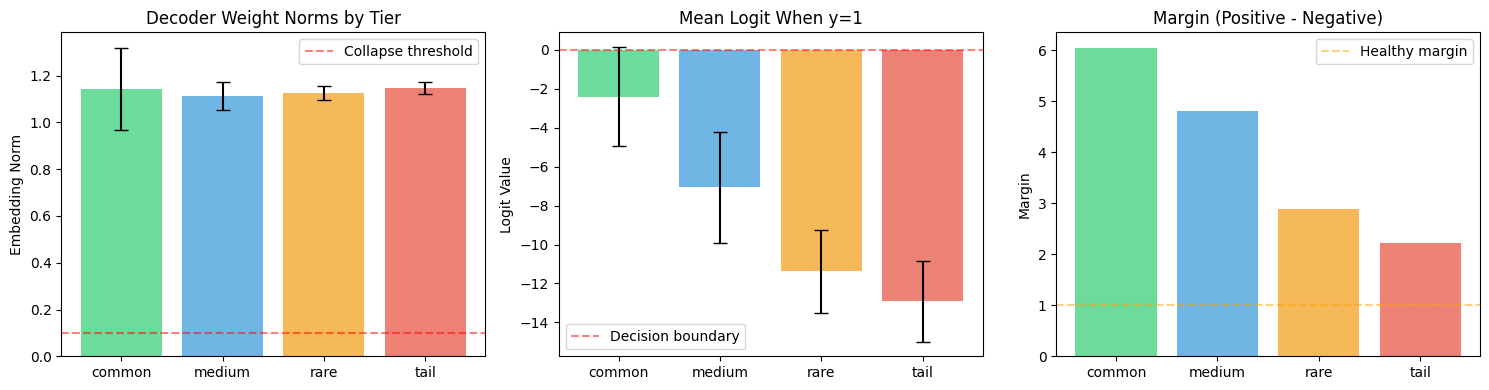

In [30]:
analyzer.plot_distributions(results)

### Learning plateau visualization and gradient starvation demonstration exp2

In [53]:
import json
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

def load_batch_metrics(json_path: str) -> list:
    """Load batch metrics from JSON file."""
    with open(json_path, 'r') as f:
        data = json.load(f)
    return data

def plot_loss_and_recall_plateau(data: list, save_path: str = None):
    """
    Plot loss and recall metrics to demonstrate the learning plateau problem.
    Shows loss decreasing initially then plateauing, alongside recall metrics.
    """
    # Extract data
    global_steps = [entry['global_step'] for entry in data]
    loss = [entry['loss'] for entry in data]
    recall_10 = [entry['recall@10'] for entry in data]
    micro_recall_10 = [entry['micro_recall@10'] for entry in data]
    
    # Create figure with dual y-axes
    fig, ax1 = plt.subplots(figsize=(12, 8))
    
    # Style configuration
    plt.style.use('seaborn-v0_8-whitegrid')
    
    # Plot loss on primary y-axis
    color_loss = '#E74C3C'  # Red
    ax1.set_xlabel('Global Step', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Loss', color=color_loss, fontsize=12, fontweight='bold')
    line1 = ax1.plot(global_steps, loss, color=color_loss, linewidth=2.5, 
                      label='Loss', alpha=0.9)
    ax1.tick_params(axis='y', labelcolor=color_loss)
    ax1.set_ylim(bottom=0)
    
    # Create secondary y-axis for recall metrics
    ax2 = ax1.twinx()
    
    color_recall = '#3498DB'  # Blue
    color_micro_recall = '#27AE60'  # Green
    
    ax2.set_ylabel('Recall@10', fontsize=12, fontweight='bold')
    line2 = ax2.plot(global_steps, recall_10, color=color_recall, linewidth=2.5, 
                      label='Recall@10', linestyle='-', alpha=0.9)
    line3 = ax2.plot(global_steps, micro_recall_10, color=color_micro_recall, linewidth=2.5, 
                      label='Micro Recall@10', linestyle='--', alpha=0.9)
    ax2.tick_params(axis='y')
    ax2.set_ylim(0, 1)
    
    # Combine legends
    lines = line1 + line2 + line3
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper right', fontsize=11, framealpha=0.95)
    
    # Title and styling
    plt.title('Learning Plateau: Loss Decreases Initially Then Plateaus\n'
              '(Intrinsic metrics also show plateau behavior)', 
              fontsize=14, fontweight='bold', pad=15)
    
    # Add annotation for plateau region
    plateau_start_idx = len(global_steps) // 4  # Approximate plateau start
    ax1.axvline(x=global_steps[plateau_start_idx], color='gray', linestyle=':', 
                alpha=0.7, linewidth=1.5)
    ax1.annotate('Plateau Region →', 
                 xy=(global_steps[plateau_start_idx], max(loss) * 0.7),
                 fontsize=10, color='gray', fontstyle='italic')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight', 
                    facecolor='white', edgecolor='none')
        print(f"Chart 1 saved to: {save_path}")
    
    plt.show()
    return fig

def plot_gradient_tier_distribution(data: list, save_path: str = None):
    """
    Plot gradient tier fractions to show how common gradients dominate over training.
    """
    # Extract data
    global_steps = [entry['global_step'] for entry in data]
    common_frac = [entry['grad_tier_common_frac'] for entry in data]
    medium_frac = [entry['grad_tier_medium_frac'] for entry in data]
    rare_frac = [entry['grad_tier_rare_frac'] for entry in data]
    tail_frac = [entry['grad_tier_tail_frac'] for entry in data]
    
    # Create figure
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Style configuration
    plt.style.use('seaborn-v0_8-whitegrid')
    
    # Color palette (from common to tail - showing dominance)
    colors = {
        'common': '#C0392B',   # Dark red (dominant)
        'medium': '#F39C12',   # Orange
        'rare': '#3498DB',     # Blue
        'tail': '#9B59B6'      # Purple
    }
    
    # Plot each tier
    ax.plot(global_steps, common_frac, color=colors['common'], linewidth=2.5, 
            label='Common Tier (dominates)', alpha=0.9)
    ax.plot(global_steps, medium_frac, color=colors['medium'], linewidth=2.5, 
            label='Medium Tier', alpha=0.9)
    ax.plot(global_steps, rare_frac, color=colors['rare'], linewidth=2.5, 
            label='Rare Tier', alpha=0.9)
    ax.plot(global_steps, tail_frac, color=colors['tail'], linewidth=2.5, 
            label='Tail Tier (starved)', alpha=0.9)
    
    # Styling
    ax.set_xlabel('Global Step', fontsize=12, fontweight='bold')
    ax.set_ylabel('Gradient Fraction', fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1)
    
    # Add horizontal reference lines
    ax.axhline(y=0.25, color='gray', linestyle='--', alpha=0.4, linewidth=1)
    ax.text(global_steps[-1] * 0.02, 0.26, 'Equal distribution (0.25)', 
            fontsize=9, color='gray', fontstyle='italic')
    
    # Title
    plt.title('Gradient Starvation: Common Labels Dominate Gradient Flow\n'
              '(Rare/Tail Tiers Receive Diminishing Gradient Signal)', 
              fontsize=14, fontweight='bold', pad=15)
    
    # Legend
    ax.legend(loc='center right', fontsize=11, framealpha=0.95)
    
    # Add fill between to emphasize the gap
    ax.fill_between(global_steps, common_frac, 0.25, 
                    where=[c > 0.25 for c in common_frac],
                    color=colors['common'], alpha=0.1, 
                    label='_nolegend_')
    
    # Annotations for start and end values
    start_common = common_frac[0]
    end_common = common_frac[-1]
    ax.annotate(f'Start: {start_common:.1%}', 
                xy=(global_steps[0], start_common),
                xytext=(global_steps[0] + len(global_steps)*5, start_common + 0.05),
                fontsize=9, color=colors['common'],
                arrowprops=dict(arrowstyle='->', color=colors['common'], alpha=0.7))
    ax.annotate(f'End: {end_common:.1%}', 
                xy=(global_steps[-1], end_common),
                xytext=(global_steps[-1] - len(global_steps)*15, end_common + 0.05),
                fontsize=9, color=colors['common'],
                arrowprops=dict(arrowstyle='->', color=colors['common'], alpha=0.7))
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight',
                    facecolor='white', edgecolor='none')
        print(f"Chart 2 saved to: {save_path}")
    
    plt.show()
    return fig



Loaded 124 batch entries

--- Generating Chart 1: Loss & Recall Plateau ---


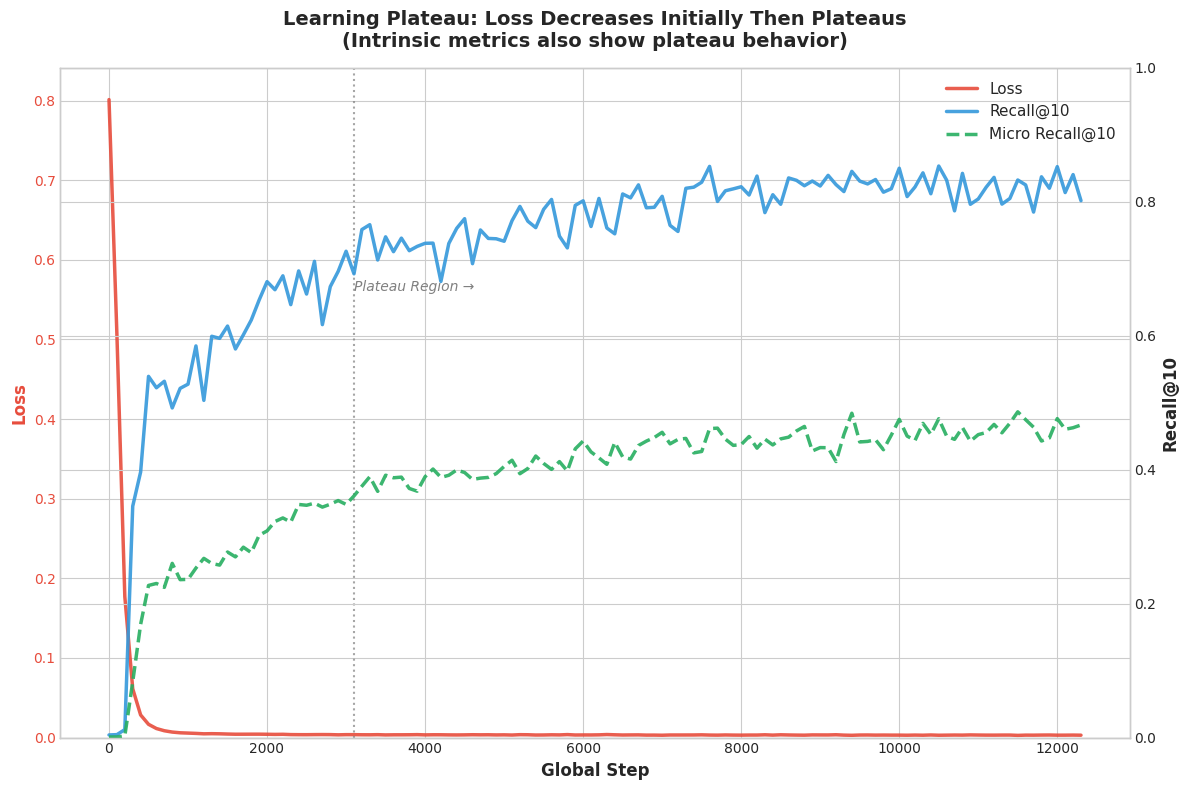

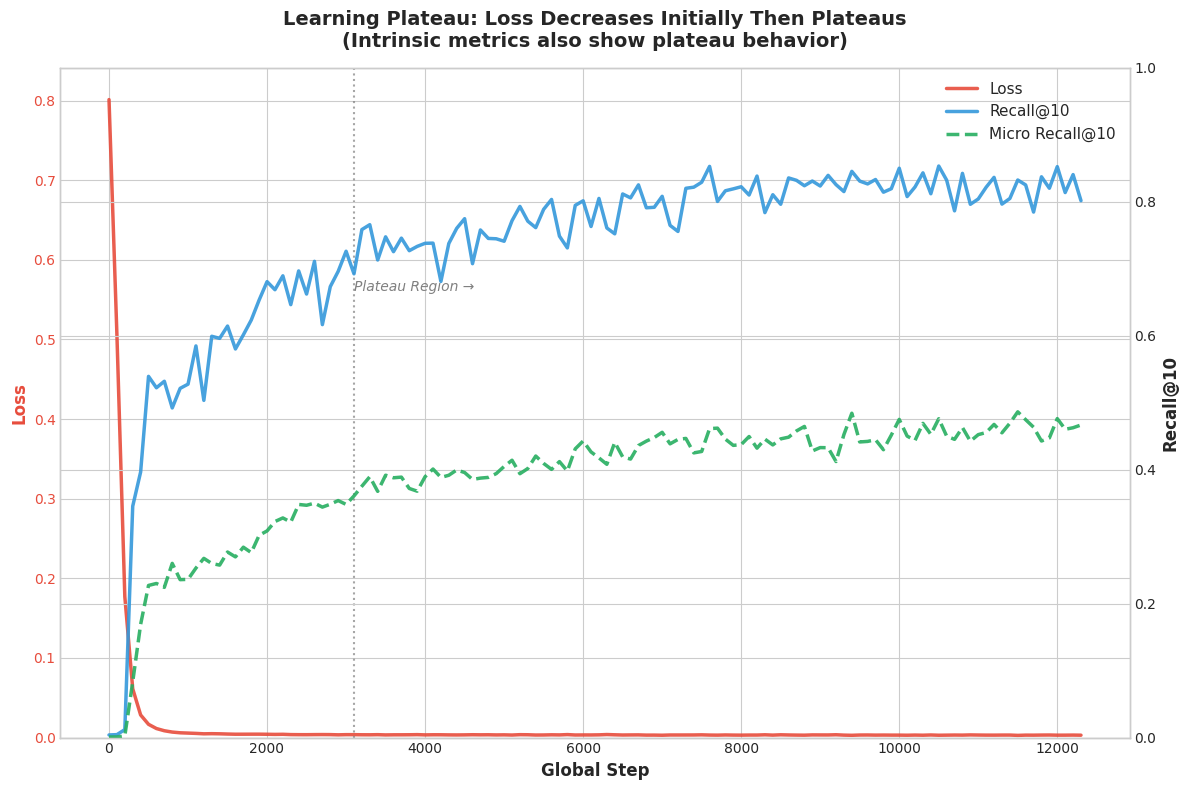

In [49]:
json_path = "logs/exp_round5_3lobs_1-5M_pretrain_multi_gpu_test_v2/exp2b_flash_learned_pool_v2_gradient/batch_metrics.json"
data = load_batch_metrics(json_path)
print(f"Loaded {len(data)} batch entries")

# Generate Chart 1: Loss and Recall Plateau
print("\n--- Generating Chart 1: Loss & Recall Plateau ---")
plot_loss_and_recall_plateau(
    data, 
    # save_path="learning_plateau_loss_recall.png"
)
        


--- Generating Chart 2: Gradient Tier Distribution ---


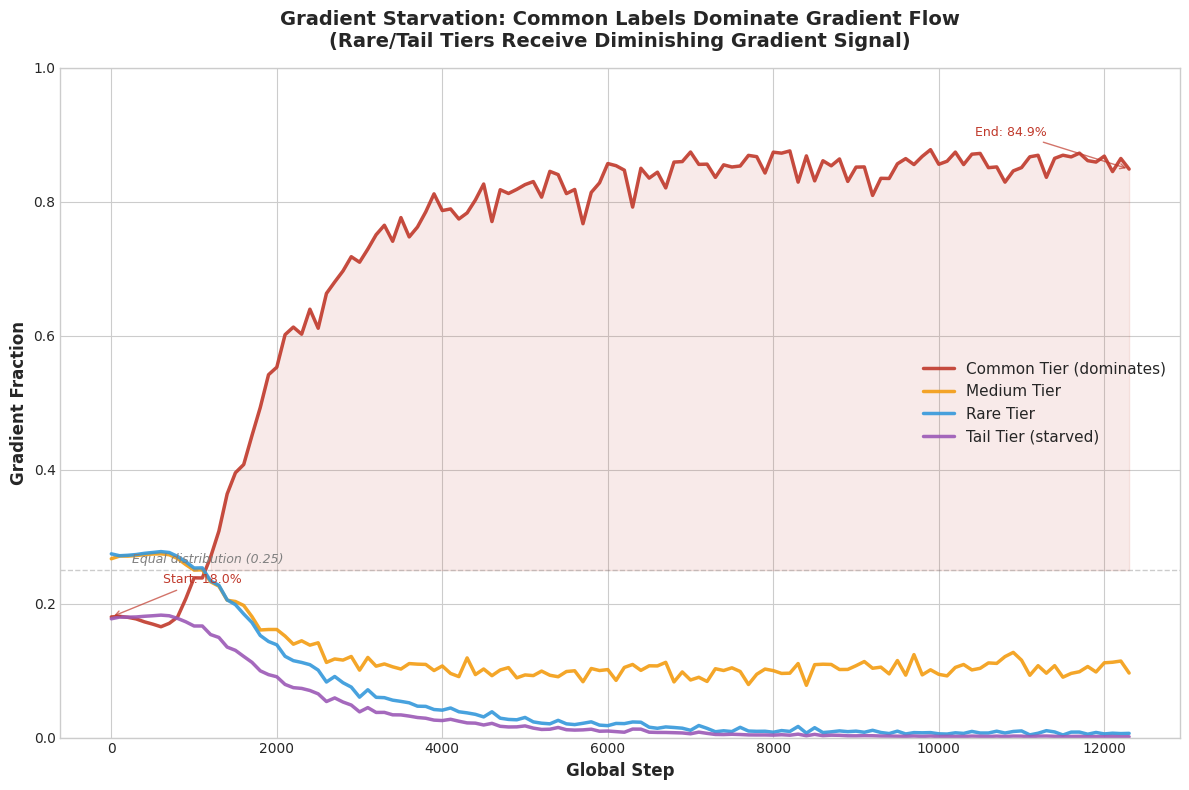

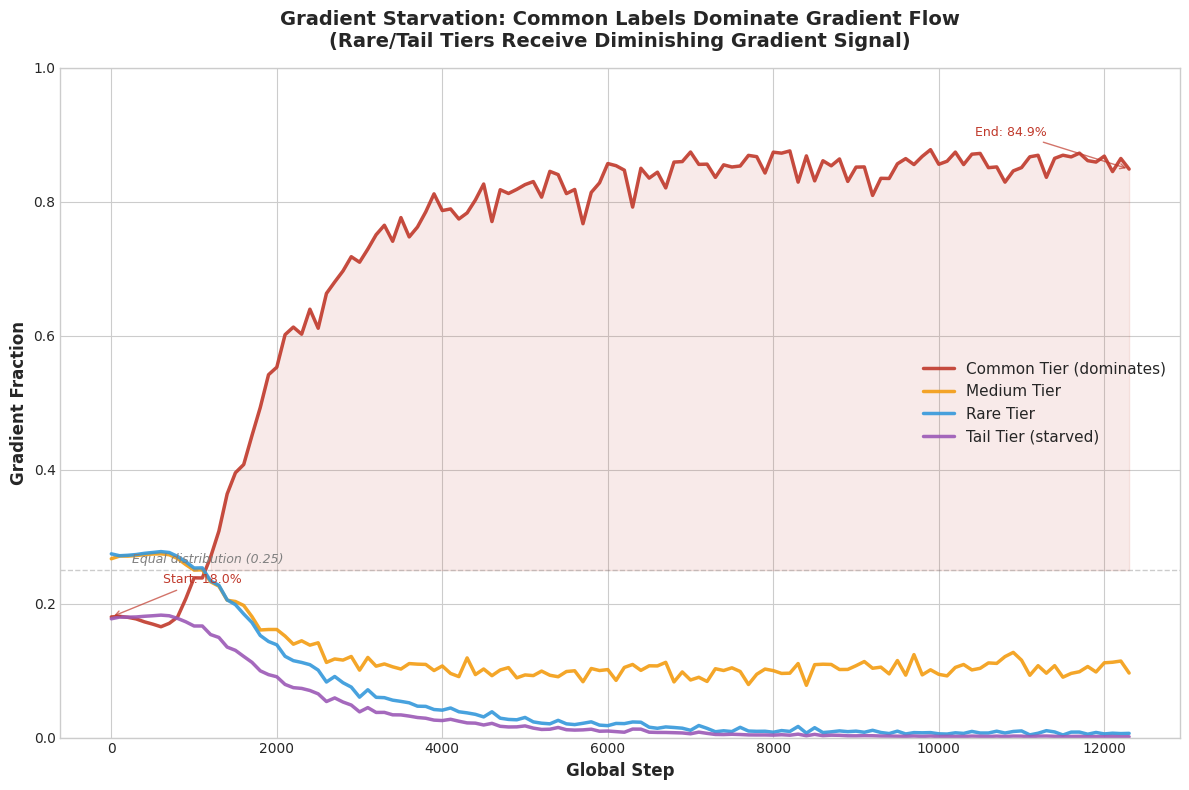

In [54]:
# Generate Chart 2: Gradient Tier Distribution
print("\n--- Generating Chart 2: Gradient Tier Distribution ---")
plot_gradient_tier_distribution(
    data,
    # save_path="gradient_starvation_distribution.png"
)

### Downstream Embedding Cluster

In [25]:
from dataclasses import dataclass
from typing import List, Optional, Tuple, Dict, Any
import warnings
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import umap

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

# Set default plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

ModuleNotFoundError: No module named 'umap'

In [26]:
!pip install umap

ERROR: Could not find a version that satisfies the requirement umap (from versions: none)
ERROR: No matching distribution found for umap


In [15]:
# =============================================================================
# DATA CLASSES - Configuration and Results
# =============================================================================

@dataclass
class UMAPConfig:
    """Configuration for UMAP dimensionality reduction."""
    n_neighbors: int = 100
    min_dist: float = 0.1
    n_components: int = 2
    metric: str = 'euclidean'
    random_state: int = 123
    verbose: bool = True


@dataclass
class ClusterConfig:
    """Configuration for cluster analysis."""
    balance_classes: bool = True
    correlation_threshold: float = 0.05
    imbalance_threshold: float = 0.20  # Downsample if minority < 20%
    random_state: int = 123


@dataclass
class CorrelationResult:
    """Result of correlation analysis between embeddings and outcome."""
    df_correlations: pd.DataFrame
    n_samples: int
    n_dimensions: int
    mean_abs_correlation: float
    max_abs_correlation: float
    top_predictor: str
    top_predictor_corr: float
    strong_predictors_count: int  # |r| > threshold
    very_strong_predictors_count: int  # |r| > 0.10


@dataclass
class ClusterSeparationResult:
    """Result of cluster separation analysis (Cohen's D)."""
    centroid_pos: np.ndarray
    centroid_neg: np.ndarray
    centroid_distance: float
    variance_pos: float
    variance_neg: float
    pooled_std: float
    cohens_d: float
    interpretation: str


@dataclass
class ClusterAnalysisResult:
    """Complete result of cluster analysis pipeline."""
    correlation_result: CorrelationResult
    separation_result: Optional[ClusterSeparationResult]
    df_balanced: pd.DataFrame
    df_viz: Optional[pd.DataFrame]  # With UMAP coordinates
    embedding_cols: List[str]
    outcome_column: str
    outcome_label: str
    embedding_name: str


In [16]:
def identify_embedding_columns(
    df: pd.DataFrame,
    prefix: str = 'embedding_'
) -> List[str]:
    """
    Identify embedding columns in a dataframe.
    
    Args:
        df: Input dataframe
        prefix: Prefix for embedding columns (default: 'embedding_')
        
    Returns:
        List of embedding column names, sorted numerically if possible
    """
    embedding_cols = [col for col in df.columns if col.startswith(prefix)]
    
    if len(embedding_cols) == 0:
        raise ValueError(f"No embedding columns found with prefix '{prefix}'")
    
    # Try numeric sorting, fallback to lexicographic if suffixes aren't purely numeric
    def _sort_key(col_name: str):
        suffix = col_name.replace(prefix, '')
        try:
            return (0, int(suffix))  # Numeric sort
        except ValueError:
            return (1, suffix)  # Lexicographic fallback
    
    return sorted(embedding_cols, key=_sort_key)


def balance_dataset_for_clustering(
    df: pd.DataFrame,
    outcome_column: str,
    config: Optional[ClusterConfig] = None,
    verbose: bool = True
) -> pd.DataFrame:
    """
    Balance dataset by downsampling majority class.
    
    This addresses class imbalance for UMAP visualization by creating
    a 50/50 split between positive and negative outcome cases.
    
    Args:
        df: Input dataframe with outcome column
        outcome_column: Name of binary outcome column (0/1)
        config: ClusterConfig with balancing parameters
        verbose: Whether to print progress
        
    Returns:
        Balanced dataframe (50/50 split) or original if already balanced
        
    Raises:
        ValueError: If outcome_column is missing or dataframe is empty
    """
    if df is None or len(df) == 0:
        raise ValueError("Input dataframe is empty or None")
    
    if outcome_column not in df.columns:
        raise ValueError(f"Outcome column '{outcome_column}' not found in dataframe. "
                        f"Available columns: {list(df.columns[:10])}...")
    
    if config is None:
        config = ClusterConfig()
    
    if not config.balance_classes:
        if verbose:
            print("⚙️ Using FULL dataset (balanced sampling disabled)")
        return df.copy()
    
    outcome_prevalence = df[outcome_column].mean()
    
    if verbose:
        print("🎯 Preparing dataset for clustering analysis...\n")
        print(f"   Outcome prevalence: {outcome_prevalence*100:.1f}%")
    
    # Check if balancing is needed
    if config.imbalance_threshold <= outcome_prevalence <= (1 - config.imbalance_threshold):
        if verbose:
            print(f"   → Reasonably balanced (minority class >= {config.imbalance_threshold*100:.0f}%)")
            print("   → Using full dataset (no downsampling needed)")
        return df.copy()
    
    if verbose:
        print(f"   → Highly imbalanced! (Minority class < {config.imbalance_threshold*100:.0f}%)")
        print("\n💡 SOLUTION: Downsample majority class to create 50/50 balance.\n")
    
    # Separate classes
    df_pos = df[df[outcome_column] == 1]
    df_neg = df[df[outcome_column] == 0]
    
    # Validate we have both classes
    if len(df_pos) == 0:
        raise ValueError(f"No positive cases (outcome_column=1) found in dataset. "
                        f"Cannot perform cluster analysis.")
    if len(df_neg) == 0:
        raise ValueError(f"No negative cases (outcome_column=0) found in dataset. "
                        f"Cannot perform cluster analysis.")
    
    if verbose:
        print(f"📊 Original IMBALANCED distribution:")
        print(f"   Outcome=1 (minority): {len(df_pos):,} ({len(df_pos)/len(df)*100:.2f}%)")
        print(f"   Outcome=0 (majority): {len(df_neg):,} ({len(df_neg)/len(df)*100:.2f}%)")
        print(f"   Ratio: 1:{len(df_neg)/len(df_pos):.1f}")
    
    # Downsample to minority size
    minority_size = min(len(df_pos), len(df_neg))
    
    if verbose:
        print(f"\n⚙️ Downsampling to {minority_size:,} samples per class...")
    
    df_pos_balanced = df_pos.sample(
        n=minority_size, 
        random_state=config.random_state, 
        replace=False
    )
    df_neg_balanced = df_neg.sample(
        n=minority_size, 
        random_state=config.random_state, 
        replace=False
    )
    
    # Combine and shuffle
    df_balanced = pd.concat([df_pos_balanced, df_neg_balanced]).sample(
        frac=1, 
        random_state=config.random_state
    ).reset_index(drop=True)
    
    if verbose:
        print(f"\n✅ BALANCED dataset created:")
        print(f"   Outcome=1: {(df_balanced[outcome_column]==1).sum():,} (50.0%)")
        print(f"   Outcome=0: {(df_balanced[outcome_column]==0).sum():,} (50.0%)")
        print(f"   Total samples: {len(df_balanced):,}")
        print(f"\n📉 Dataset reduction: {len(df):,} → {len(df_balanced):,} "
              f"({len(df_balanced)/len(df)*100:.1f}% of original)")
    
    return df_balanced


In [28]:
def visualize_correlation_analysis(
    correlation_result: CorrelationResult,
    outcome_label: str = "Outcome",
    top_n: int = 20,
    figsize: Tuple[int, int] = (14, 6),
    show_plot: bool = True
) -> plt.Figure:
    """
    Visualize correlation analysis results.
    
    Args:
        correlation_result: Result from compute_embedding_correlations
        outcome_label: Human-readable label for outcome
        top_n: Number of top dimensions to show in bar chart
        figsize: Figure size
        show_plot: Whether to display the plot
        
    Returns:
        matplotlib Figure object
    """
    df_corr = correlation_result.df_correlations
    
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    # Plot 1: Top N embedding dimensions
    ax = axes[0]
    top_embs = df_corr.head(top_n)
    colors = ['red' if x < 0 else 'green' for x in top_embs['correlation']]
    ax.barh(range(len(top_embs)), top_embs['correlation'], color=colors, alpha=0.7)
    ax.set_yticks(range(len(top_embs)))
    ax.set_yticklabels(top_embs['embedding'])
    ax.set_xlabel(f'Correlation with {outcome_label}')
    ax.set_title(f'Top {top_n} Embedding Dimensions by {outcome_label} Correlation')
    ax.axvline(x=0, color='black', linestyle='--', linewidth=1)
    ax.grid(alpha=0.3)
    
    # Plot 2: Distribution of correlations
    ax = axes[1]
    ax.hist(df_corr['correlation'], bins=50, alpha=0.7, edgecolor='black')
    ax.set_xlabel(f'Correlation with {outcome_label}')
    ax.set_ylabel('Number of Embeddings')
    ax.set_title('Distribution of Embedding-Outcome Correlations')
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero')
    ax.legend()
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    
    if show_plot:
        plt.show()
    
    return fig


def visualize_effect_size_thresholds(
    correlation_result: CorrelationResult,
    outcome_label: str = "Outcome",
    figsize: Tuple[int, int] = (16, 5),
    show_plot: bool = True,
    verbose: bool = True
) -> plt.Figure:
    """
    Visualize effect size thresholds for correlation analysis.
    
    Args:
        correlation_result: Result from compute_embedding_correlations
        outcome_label: Human-readable label for outcome
        figsize: Figure size
        show_plot: Whether to display the plot
        verbose: Whether to print threshold analysis
        
    Returns:
        matplotlib Figure object
    """
    df_corr = correlation_result.df_correlations
    n_dims = correlation_result.n_dimensions
    
    if verbose:
        print("🔬 Analyzing correlation thresholds...\n")
        
        # Effect size interpretation
        thresholds = {
            'Negligible': 0.01,
            'Very Small': 0.02,
            'Small': 0.05,
            'Small-Medium': 0.10,
            'Medium': 0.20,
            'Large': 0.30,
            'Very Large': 0.50
        }
        
        print(f"📏 Effect Size Distribution:")
        for label, thresh in thresholds.items():
            count = (df_corr['abs_correlation'] >= thresh).sum()
            pct = count / n_dims * 100
            print(f"   |r| ≥ {thresh:.2f} ({label:>12}): {count:3d} / {n_dims} ({pct:5.1f}%)")
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    ax = axes[0]
    ax.hist(df_corr['abs_correlation'], bins=50, alpha=0.7, edgecolor='black')
    ax.axvline(x=0.01, color='gray', linestyle='--', linewidth=2, 
               label='Negligible (0.01)', alpha=0.5)
    ax.axvline(x=0.05, color='orange', linestyle='--', linewidth=2, label='Small (0.05)')
    ax.axvline(x=0.10, color='red', linestyle='--', linewidth=2, label='Medium (0.10)')
    ax.axvline(x=0.20, color='darkred', linestyle='--', linewidth=3, label='Large (0.20)')
    ax.set_xlabel(f'Absolute Correlation with {outcome_label}')
    ax.set_ylabel('Number of Embedding Dimensions')
    ax.set_title(f'Distribution of Embedding-{outcome_label} Correlations\n'
                 '(Multiple Effect Size Thresholds)')
    ax.legend()
    ax.grid(alpha=0.3)
    
    ax = axes[1]
    sorted_corr = np.sort(df_corr['abs_correlation'].values)[::-1]
    ax.plot(range(1, n_dims + 1), sorted_corr, linewidth=2, color='blue')
    ax.axhline(y=0.01, color='gray', linestyle='--', alpha=0.5, label='Negligible')
    ax.axhline(y=0.05, color='orange', linestyle='--', label='Small')
    ax.axhline(y=0.10, color='red', linestyle='--', label='Medium')
    ax.axhline(y=0.20, color='darkred', linestyle='--', linewidth=2, label='Large')
    ax.set_xlabel('Embedding Dimension Rank (Best to Worst)')
    ax.set_ylabel('Absolute Correlation')
    ax.set_title('Ranked Embedding Correlations\n(How Many Dimensions Are "Strong"?)')
    ax.legend()
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    
    if show_plot:
        plt.show()
    
    return fig


# =============================================================================
# UMAP PROJECTION
# =============================================================================

def run_umap_projection(
    df: pd.DataFrame,
    embedding_cols: List[str],
    config: Optional[UMAPConfig] = None,
    verbose: bool = True
) -> Tuple[pd.DataFrame, np.ndarray, float]:
    """
    Run UMAP dimensionality reduction (256D → 2D).
    
    Args:
        df: Input dataframe with embedding columns
        embedding_cols: List of embedding column names
        config: UMAPConfig with UMAP parameters
        verbose: Whether to print progress
        
    Returns:
        Tuple of (dataframe with umap_x/umap_y columns, 2D embedding array, runtime in seconds)
        
    Raises:
        ValueError: If embedding columns are missing or dataframe is empty
    """
    if df is None or len(df) == 0:
        raise ValueError("Input dataframe is empty or None")
    
    if not embedding_cols:
        raise ValueError("embedding_cols list is empty")
    
    missing_cols = [col for col in embedding_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing embedding columns in dataframe: {missing_cols[:5]}... "
                        f"(showing first 5 of {len(missing_cols)})")
    
    if config is None:
        config = UMAPConfig()
    
    if verbose:
        print("🗺️ Running UMAP dimensionality reduction (256D → 2D)...")
        print(f"   Samples: {len(df):,}")
        print(f"   Parameters: n_neighbors={config.n_neighbors}, min_dist={config.min_dist}")
        print(f"   Estimated time: {len(df)//50000 + 1}-{len(df)//20000 + 2} minutes\n")
    
    X = df[embedding_cols].values
    
    start_time = time.time()
    
    reducer = umap.UMAP(
        n_components=config.n_components,
        n_neighbors=config.n_neighbors,
        min_dist=config.min_dist,
        metric=config.metric,
        random_state=config.random_state,
        verbose=config.verbose
    )
    
    embedding_2d = reducer.fit_transform(X)
    umap_time = time.time() - start_time
    
    # Add UMAP coordinates to dataframe
    df_result = df.copy()
    df_result['umap_x'] = embedding_2d[:, 0]
    df_result['umap_y'] = embedding_2d[:, 1]
    
    if verbose:
        print(f"\n✅ UMAP complete in {umap_time/60:.1f} minutes ({umap_time:.1f} seconds)")
        print(f"   2D embedding shape: {embedding_2d.shape}")
    
    return df_result, embedding_2d, umap_time


# =============================================================================
# CLUSTER SEPARATION QUANTIFICATION
# =============================================================================

def compute_cluster_separation(
    df: pd.DataFrame,
    outcome_column: str,
    umap_x_col: str = 'umap_x',
    umap_y_col: str = 'umap_y',
    outcome_label: str = "Outcome",
    verbose: bool = True
) -> ClusterSeparationResult:
    """
    Compute cluster separation metrics (Cohen's D) from UMAP projection.
    
    Args:
        df: Dataframe with UMAP coordinates and outcome
        outcome_column: Name of binary outcome column (0/1)
        umap_x_col: Name of UMAP x coordinate column
        umap_y_col: Name of UMAP y coordinate column
        outcome_label: Human-readable label for outcome
        verbose: Whether to print progress
        
    Returns:
        ClusterSeparationResult with separation metrics
        
    Raises:
        ValueError: If required columns are missing
    """
    # Validate required columns exist
    required_cols = [outcome_column, umap_x_col, umap_y_col]
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}. "
                        f"Ensure UMAP has been run first.")
    
    if verbose:
        print(f"📊 Quantifying cluster separation for {outcome_label}...\n")
    
    # Split by outcome
    df_neg = df[df[outcome_column] == 0]
    df_pos = df[df[outcome_column] == 1]
    
    # Calculate centroids
    centroid_neg = df_neg[[umap_x_col, umap_y_col]].mean().values
    centroid_pos = df_pos[[umap_x_col, umap_y_col]].mean().values
    centroid_distance = np.linalg.norm(centroid_pos - centroid_neg)
    
    # Within-group variance
    var_neg = df_neg[[umap_x_col, umap_y_col]].var().mean()
    var_pos = df_pos[[umap_x_col, umap_y_col]].var().mean()
    
    # Cohen's D
    pooled_std = np.sqrt((var_neg + var_pos) / 2)
    cohens_d = centroid_distance / pooled_std if pooled_std > 0 else 0.0
    
    # Interpretation
    if cohens_d < 0.2:
        interpretation = "Negligible (no clustering)"
    elif cohens_d < 0.5:
        interpretation = "Small effect"
    elif cohens_d < 0.8:
        interpretation = "Medium effect (noticeable separation)"
    else:
        interpretation = "Large effect (strong clustering)"
    
    result = ClusterSeparationResult(
        centroid_pos=centroid_pos,
        centroid_neg=centroid_neg,
        centroid_distance=centroid_distance,
        variance_pos=var_pos,
        variance_neg=var_neg,
        pooled_std=pooled_std,
        cohens_d=cohens_d,
        interpretation=interpretation
    )
    
    if verbose:
        print(f"🎯 Cluster Centroids:")
        print(f"   {outcome_label}=0 Centroid: ({centroid_neg[0]:.3f}, {centroid_neg[1]:.3f})")
        print(f"   {outcome_label}=1 Centroid: ({centroid_pos[0]:.3f}, {centroid_pos[1]:.3f})")
        print(f"   Euclidean Distance: {centroid_distance:.3f}")
        
        print(f"\n📏 Within-Group Variance:")
        print(f"   {outcome_label}=0 Variance: {var_neg:.3f}")
        print(f"   {outcome_label}=1 Variance: {var_pos:.3f}")
        
        print(f"\n📈 Effect Size (Cohen's D): {cohens_d:.3f}")
        print(f"   Interpretation: {interpretation}")
        
        print(f"\n💡 What this means:")
        if cohens_d >= 0.5:
            print(f"   ✅ Embeddings meaningfully separate {outcome_label} groups!")
            print(f"   ✅ Transformer captures clinical patterns relevant to {outcome_label}")
        else:
            print(f"   ⚠️ Limited separation between {outcome_label} groups")
            print(f"   ⚠️ Embeddings may not strongly capture this specific outcome")
    
    return result


# =============================================================================
# VISUALIZATION
# =============================================================================

def visualize_clusters(
    df: pd.DataFrame,
    outcome_column: str,
    outcome_label: str = "Outcome",
    umap_x_col: str = 'umap_x',
    umap_y_col: str = 'umap_y',
    figsize: Tuple[int, int] = (16, 12),
    show_plot: bool = True
) -> plt.Figure:
    """
    Create 4-panel cluster visualization.
    
    Panels:
    - Top-Left: All points (gradient by outcome)
    - Top-Right: Negative cases only (blue)
    - Bottom-Left: Positive cases only (red)
    - Bottom-Right: Risk heatmap
    
    Args:
        df: Dataframe with UMAP coordinates and outcome
        outcome_column: Name of binary outcome column (0/1)
        outcome_label: Human-readable label for outcome
        umap_x_col: Name of UMAP x coordinate column
        umap_y_col: Name of UMAP y coordinate column
        figsize: Figure size
        show_plot: Whether to display the plot
        
    Returns:
        matplotlib Figure object
    """
    print("🎨 Creating visualizations...\n")
    
    # Validate required columns exist
    required_cols = [outcome_column, umap_x_col, umap_y_col]
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")
    
    # Split by outcome
    df_neg = df[df[outcome_column] == 0]
    df_pos = df[df[outcome_column] == 1]
    
    if len(df_neg) == 0 or len(df_pos) == 0:
        raise ValueError(f"Cannot visualize: one or both outcome classes are empty. "
                        f"Positive: {len(df_pos)}, Negative: {len(df_neg)}")
    
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    
    # Plot 1: All points colored by outcome (gradient)
    ax = axes[0, 0]
    scatter = ax.scatter(
        df[umap_x_col], 
        df[umap_y_col],
        c=df[outcome_column],
        cmap='RdYlGn_r',  # Red = high risk (1), Green = low risk (0)
        alpha=0.2,
        s=5,
        edgecolors='none'
    )
    ax.set_xlabel('UMAP Dimension 1')
    ax.set_ylabel('UMAP Dimension 2')
    ax.set_title(f'All Points: Gradient View\nColored by {outcome_label}')
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label(f'{outcome_label} (0=No, 1=Yes)')
    ax.grid(alpha=0.3)
    
    # Plot 2: Negative cases only
    ax = axes[0, 1]
    ax.scatter(df_neg[umap_x_col], df_neg[umap_y_col], 
               c='blue', alpha=0.3, s=3, edgecolors='none')
    ax.set_xlabel('UMAP Dimension 1')
    ax.set_ylabel('UMAP Dimension 2')
    ax.set_title(f'No {outcome_label} Cases Only\n(n={len(df_neg):,})')
    ax.grid(alpha=0.3)
    
    # Plot 3: Positive cases only
    ax = axes[1, 0]
    ax.scatter(df_pos[umap_x_col], df_pos[umap_y_col], 
               c='red', alpha=0.3, s=3, edgecolors='none')
    ax.set_xlabel('UMAP Dimension 1')
    ax.set_ylabel('UMAP Dimension 2')
    ax.set_title(f'{outcome_label} Cases Only\n(n={len(df_pos):,})')
    ax.grid(alpha=0.3)
    
    # Plot 4: Risk heatmap
    ax = axes[1, 1]
    
    # Create 2D histogram
    h, xedges, yedges = np.histogram2d(
        df[umap_x_col], 
        df[umap_y_col], 
        bins=50
    )
    
    h_pos, _, _ = np.histogram2d(
        df_pos[umap_x_col], 
        df_pos[umap_y_col], 
        bins=[xedges, yedges]
    )
    
    # Calculate outcome prevalence per bin
    with np.errstate(divide='ignore', invalid='ignore'):
        prevalence = h_pos / h
        prevalence = np.nan_to_num(prevalence, nan=0)
    
    im = ax.imshow(
        prevalence.T, 
        origin='lower',
        extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
        cmap='RdYlGn_r',
        aspect='auto',
        alpha=0.8,
        vmin=0,
        vmax=1
    )
    
    ax.set_xlabel('UMAP Dimension 1')
    ax.set_ylabel('UMAP Dimension 2')
    ax.set_title(f'{outcome_label} Risk Heatmap\n(Red = High Risk, Green = Low Risk)')
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(f'{outcome_label} Prevalence (0-100%)')
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    
    if show_plot:
        plt.show()
    
    print("✅ Visualizations complete")
    print(f"\n💡 How to Interpret the 4-Panel View:")
    print(f"\n   📊 TOP LEFT (Gradient): Overall distribution of both classes")
    print(f"   📊 TOP RIGHT (Blue): Where No-{outcome_label} cases cluster")
    print(f"   📊 BOTTOM LEFT (Red): Where {outcome_label} cases cluster")
    print(f"   📊 BOTTOM RIGHT (Heatmap): Risk 'hot zones' (red) vs 'safe zones' (green)")
    print(f"\n   ✅ GOOD CLUSTERING: Blue and Red plots show DIFFERENT dense regions")
    print(f"   ❌ POOR CLUSTERING: Blue and Red plots look identical")
    
    return fig


def visualize_alternative_comparison(
    df_viz: pd.DataFrame,
    outcome_column: str,
    cohens_d: float,
    embedding_name: str,
    outcome_label: str = "Outcome",
    umap_x_col: str = 'umap_x',
    umap_y_col: str = 'umap_y',
    figsize: Tuple[int, int] = (16, 6),
    show_plot: bool = True
) -> plt.Figure:
    """
    Visualize alternative embedding with scatter and heatmap.
    
    Args:
        df_viz: Dataframe with UMAP coordinates and outcome
        outcome_column: Name of binary outcome column (0/1)
        cohens_d: Cohen's D value for this embedding
        embedding_name: Name of embedding source
        outcome_label: Human-readable label for outcome
        umap_x_col: Name of UMAP x coordinate column
        umap_y_col: Name of UMAP y coordinate column
        figsize: Figure size
        show_plot: Whether to display the plot
        
    Returns:
        matplotlib Figure object
    """
    print(f"🎨 Creating visualizations for {embedding_name}...\n")
    
    # Validate required columns exist
    required_cols = [outcome_column, umap_x_col, umap_y_col]
    missing_cols = [col for col in required_cols if col not in df_viz.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")
    
    df_neg = df_viz[df_viz[outcome_column] == 0]
    df_pos = df_viz[df_viz[outcome_column] == 1]
    
    if len(df_neg) == 0 or len(df_pos) == 0:
        raise ValueError(f"Cannot visualize: one or both outcome classes are empty. "
                        f"Positive: {len(df_pos)}, Negative: {len(df_neg)}")
    
    centroid_neg = df_neg[[umap_x_col, umap_y_col]].mean().values
    centroid_pos = df_pos[[umap_x_col, umap_y_col]].mean().values
    
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    # Plot 1: Scatter with centroids
    ax = axes[0]
    ax.scatter(df_neg[umap_x_col], df_neg[umap_y_col], 
               c='lightblue', alpha=0.3, s=10, 
               label=f'No {outcome_label} (n={len(df_neg):,})', edgecolors='none')
    ax.scatter(df_pos[umap_x_col], df_pos[umap_y_col], 
               c='red', alpha=0.6, s=20, 
               label=f'{outcome_label} (n={len(df_pos):,})', 
               edgecolors='darkred', linewidths=0.5)
    ax.scatter(*centroid_neg, marker='X', s=300, c='blue', 
               edgecolors='black', linewidths=2, label='Neg Centroid', zorder=10)
    ax.scatter(*centroid_pos, marker='X', s=300, c='darkred', 
               edgecolors='black', linewidths=2, label='Pos Centroid', zorder=10)
    ax.set_xlabel('UMAP Dimension 1')
    ax.set_ylabel('UMAP Dimension 2')
    ax.set_title(f'{embedding_name} Embeddings\nCohen\'s D = {cohens_d:.3f}')
    ax.legend()
    ax.grid(alpha=0.3)
    
    # Plot 2: Heatmap
    ax = axes[1]
    h, xedges, yedges = np.histogram2d(
        df_viz[umap_x_col], df_viz[umap_y_col], bins=50
    )
    h_pos, _, _ = np.histogram2d(
        df_pos[umap_x_col], df_pos[umap_y_col], bins=[xedges, yedges]
    )
    
    with np.errstate(divide='ignore', invalid='ignore'):
        prevalence = h_pos / h
        prevalence = np.nan_to_num(prevalence, nan=0)
    
    im = ax.imshow(prevalence.T, origin='lower',
                   extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
                   cmap='RdYlGn_r', aspect='auto', alpha=0.8)
    ax.set_xlabel('UMAP Dimension 1')
    ax.set_ylabel('UMAP Dimension 2')
    ax.set_title(f'{outcome_label} Risk Density Map\n({embedding_name})')
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(f'{outcome_label} Prevalence')
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    
    if show_plot:
        plt.show()
    
    print("✅ Visualizations complete")
    
    return fig


# =============================================================================
# SUMMARY REPORTING
# =============================================================================

def generate_cluster_summary(
    correlation_result: CorrelationResult,
    separation_result: ClusterSeparationResult,
    embedding_name: str,
    outcome_label: str = "Outcome",
    correlation_threshold: float = 0.05,
    verbose: bool = True
) -> Dict[str, Any]:
    """
    Generate summary of cluster analysis findings.
    
    Args:
        correlation_result: Result from compute_embedding_correlations
        separation_result: Result from compute_cluster_separation
        embedding_name: Name of embedding source
        outcome_label: Human-readable label for outcome
        correlation_threshold: Threshold for strong predictor count
        verbose: Whether to print summary
        
    Returns:
        Dictionary with summary statistics
    """
    cohens_d = separation_result.cohens_d
    interpretation = separation_result.interpretation
    
    summary = {
        'embedding_name': embedding_name,
        'outcome_label': outcome_label,
        'n_samples': correlation_result.n_samples,
        'n_dimensions': correlation_result.n_dimensions,
        
        # Correlation metrics
        'top_predictor': correlation_result.top_predictor,
        'top_predictor_corr': correlation_result.top_predictor_corr,
        'mean_abs_correlation': correlation_result.mean_abs_correlation,
        'strong_predictors_count': correlation_result.strong_predictors_count,
        'very_strong_predictors_count': correlation_result.very_strong_predictors_count,
        
        # Cluster separation metrics
        'centroid_distance': separation_result.centroid_distance,
        'cohens_d': cohens_d,
        'interpretation': interpretation,
        
        # Business implication
        'recommendation': _get_business_recommendation(cohens_d, outcome_label)
    }
    
    if verbose:
        print("="*80)
        print(f"🎯 KEY FINDINGS: Do Embeddings Cluster by {outcome_label}?")
        print("="*80)
        
        print(f"\n1️⃣ CLUSTER SEPARATION (UMAP 2D):")
        print(f"   - Embedding Source: {embedding_name}")
        print(f"   - Centroid Distance: {separation_result.centroid_distance:.3f}")
        print(f"   - Cohen's D Effect Size: {cohens_d:.3f} ({interpretation})")
        
        sep_msg = ('✅ Embeddings separate outcome groups well' if cohens_d > 0.5 
                   else '⚠️ Limited separation' if cohens_d > 0.3 
                   else '❌ Minimal/no separation')
        print(f"   - Interpretation: {sep_msg}")
        
        print(f"\n2️⃣ PREDICTIVE EMBEDDING DIMENSIONS:")
        print(f"   - Most Predictive: {correlation_result.top_predictor} "
              f"(r={correlation_result.top_predictor_corr:.4f})")
        print(f"   - Mean Abs Correlation: {correlation_result.mean_abs_correlation:.4f}")
        print(f"   - Strong Predictors (|r| > {correlation_threshold}): "
              f"{correlation_result.strong_predictors_count} / {correlation_result.n_dimensions}")
        print(f"   - Very Strong Predictors (|r| > 0.10): "
              f"{correlation_result.very_strong_predictors_count} / {correlation_result.n_dimensions}")
        
        print(f"\n3️⃣ BUSINESS IMPLICATIONS:")
        for line in summary['recommendation']:
            print(f"   {line}")
        
        print(f"\n{'='*80}")
    
    return summary


def _get_business_recommendation(cohens_d: float, outcome_label: str) -> List[str]:
    """Get business recommendation based on Cohen's D."""
    if cohens_d >= 0.8:
        return [
            f"✅✅ Embeddings are EXCEPTIONALLY VALUABLE for {outcome_label} prediction",
            "✅ Very clear visual separation between outcome groups",
            "✅ Embeddings likely outperform baseline features alone",
            "✅ Strong candidate for standalone risk stratification"
        ]
    elif cohens_d >= 0.5:
        return [
            f"✅ Embeddings are HIGHLY VALUABLE for {outcome_label} prediction",
            "✅ Clear visual separation between outcome groups",
            "✅ Consider using embeddings + baseline features (hybrid model)",
            "✅ Embeddings add meaningful signal beyond demographics"
        ]
    elif cohens_d >= 0.3:
        return [
            f"⚠️ Embeddings provide MODERATE value for {outcome_label} prediction",
            "⚠️ Some visual separation, but not dramatic",
            "⚠️ Best used in combination with baseline features",
            "⚠️ May improve model performance incrementally"
        ]
    else:
        return [
            f"❌ Embeddings show LIMITED clustering by {outcome_label}",
            "❌ Minimal visual separation between outcome groups",
            "❌ May capture other clinical patterns, but not this specific outcome",
            "❌ Consider: (1) Different outcome? (2) Different embedding architecture?"
        ]


def compare_embeddings(
    result_a: ClusterAnalysisResult,
    result_b: ClusterAnalysisResult,
    verbose: bool = True
) -> Dict[str, Any]:
    """
    Compare two embedding sources.
    
    Args:
        result_a: First embedding analysis result (must have run UMAP)
        result_b: Second embedding analysis result (must have run UMAP)
        verbose: Whether to print comparison
        
    Returns:
        Dictionary with comparison metrics
        
    Raises:
        ValueError: If either result lacks separation_result (UMAP not run)
    """
    if result_a.separation_result is None:
        raise ValueError(f"result_a ({result_a.embedding_name}) has no separation_result. "
                        "Run with run_umap=True to enable comparison.")
    if result_b.separation_result is None:
        raise ValueError(f"result_b ({result_b.embedding_name}) has no separation_result. "
                        "Run with run_umap=True to enable comparison.")
    
    cohens_d_a = result_a.separation_result.cohens_d
    cohens_d_b = result_b.separation_result.cohens_d
    
    mean_corr_a = result_a.correlation_result.mean_abs_correlation
    mean_corr_b = result_b.correlation_result.mean_abs_correlation
    
    diff_cohens = cohens_d_b - cohens_d_a
    diff_corr = mean_corr_b - mean_corr_a
    
    # Determine winner
    if diff_cohens > 0.05:
        winner = result_b.embedding_name
        winner_msg = f"✅ {result_b.embedding_name} WINS! Better clustering"
    elif diff_cohens < -0.05:
        winner = result_a.embedding_name
        winner_msg = f"✅ {result_a.embedding_name} WINS! Better clustering"
    else:
        winner = "TIE"
        winner_msg = "➖ TIE: Similar clustering performance"
    
    comparison = {
        'embedding_a': result_a.embedding_name,
        'embedding_b': result_b.embedding_name,
        'cohens_d_a': cohens_d_a,
        'cohens_d_b': cohens_d_b,
        'cohens_d_diff': diff_cohens,
        'mean_corr_a': mean_corr_a,
        'mean_corr_b': mean_corr_b,
        'mean_corr_diff': diff_corr,
        'winner': winner,
        'winner_msg': winner_msg
    }
    
    if verbose:
        print("="*80)
        print(f"🔄 COMPARISON: {result_a.embedding_name} vs {result_b.embedding_name}")
        print("="*80)
        
        print(f"\n📊 Centroid Distance:")
        print(f"   {result_a.embedding_name}: {result_a.separation_result.centroid_distance:.3f}")
        print(f"   {result_b.embedding_name}: {result_b.separation_result.centroid_distance:.3f}")
        
        print(f"\n📊 Mean Absolute Correlation:")
        print(f"   {result_a.embedding_name}: {mean_corr_a:.4f}")
        print(f"   {result_b.embedding_name}: {mean_corr_b:.4f}")
        print(f"   Difference: {diff_corr:+.4f} "
              f"{'✅ BETTER' if diff_corr > 0 else '❌ WORSE' if diff_corr < 0 else '➖ SAME'}")
        
        print(f"\n📊 Cohen's D (KEY METRIC):")
        print(f"   {result_a.embedding_name}: {cohens_d_a:.3f} ({result_a.separation_result.interpretation})")
        print(f"   {result_b.embedding_name}: {cohens_d_b:.3f} ({result_b.separation_result.interpretation})")
        pct_change = (diff_cohens / cohens_d_a) * 100 if cohens_d_a > 0 else 0
        print(f"   Difference: {diff_cohens:+.3f} ({pct_change:+.1f}%)")
        
        print(f"\n🏆 WINNER: {winner_msg}")
        print("="*80)
    
    return comparison




In [29]:
def load_embeddings_from_local(
    embedding_path: str,
    verbose: bool = True
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Load embeddings from local NPZ file.
    
    Supports:
    - Direct path to .npz file
    - Directory containing embeddings_*.npz files (uses most recent)
    - Glob pattern (uses most recent match)
    
    Args:
        embedding_path: Path to NPZ file, directory, or glob pattern
        verbose: Whether to print loading info
        
    Returns:
        Tuple of (embeddings, individual_ids, index_dts)
        - embeddings: numpy array [num_members, embedding_dim]
        - individual_ids: numpy array of member IDs
        - index_dts: numpy array of index dates
        
    Example:
        embeddings, ids, dates = load_embeddings_from_local(
            "embedding_output/exp2b_flash_learned_pool/"
        )
    """
    if os.path.isdir(embedding_path):
        npz_files = glob.glob(os.path.join(embedding_path, "embeddings_*.npz"))
        if not npz_files:
            raise FileNotFoundError(f"No NPZ files found in {embedding_path}")
        npz_path = sorted(npz_files)[-1]  # Use most recent
        if verbose:
            print(f"📁 Found {len(npz_files)} NPZ files, using most recent: {os.path.basename(npz_path)}")
    elif '*' in embedding_path:
        npz_files = glob.glob(embedding_path)
        if not npz_files:
            raise FileNotFoundError(f"No files matching pattern: {embedding_path}")
        npz_path = sorted(npz_files)[-1]
        if verbose:
            print(f"📁 Found {len(npz_files)} matching files, using: {npz_path}")
    else:
        npz_path = embedding_path
        if not os.path.exists(npz_path):
            raise FileNotFoundError(f"File not found: {npz_path}")
    
    data = np.load(npz_path, allow_pickle=True)
    
    embeddings = data['embeddings']
    individual_ids = data['individual_ids']
    index_dts = data['index_dts']
    
    if verbose:
        print(f"✅ Loaded embeddings from: {npz_path}")
        print(f"   Shape: {embeddings.shape}")
        print(f"   Members: {len(individual_ids):,}")
    
    return embeddings, individual_ids, index_dts

def load_tabular_features_from_bigquery(
    table_id: str,
    project_id: Optional[str] = None,
    columns: Optional[List[str]] = None,
    verbose: bool = True
) -> pd.DataFrame:
    """
    Load tabular features from BigQuery table.
    
    Args:
        table_id: Full table ID (project.dataset.table)
        project_id: GCP project ID (optional if table_id is fully qualified)
        columns: Specific columns to load (None = all columns)
        verbose: Whether to print loading info
        
    Returns:
        DataFrame with features and outcome columns
        
    Example:
        df_features = load_tabular_features_from_bigquery(
            "edp-prod-storage.edp_ent_sdoheir_cns.a964286_commercial_ip_features"
        )
    """
    try:
        from google.cloud import bigquery
    except ImportError:
        raise ImportError("google-cloud-bigquery is required for BigQuery loading. "
                         "Install with: pip install google-cloud-bigquery")
    
    client = bigquery.Client(project=project_id) if project_id else bigquery.Client()
    
    if columns:
        col_str = ", ".join(columns)
        query = f"SELECT {col_str} FROM `{table_id}`"
    else:
        query = f"SELECT * FROM `{table_id}`"
    
    if verbose:
        print(f"📥 Loading features from BigQuery: {table_id}")
    
    df = client.query(query).to_dataframe()
    
    if verbose:
        print(f"✅ Loaded {len(df):,} rows with {len(df.columns)} columns")
    
    return df


def create_embedding_dataframe(
    embeddings: np.ndarray,
    individual_ids: np.ndarray,
    index_dts: np.ndarray
) -> pd.DataFrame:
    """
    Convert embedding arrays to a DataFrame.
    
    Args:
        embeddings: numpy array [num_members, embedding_dim]
        individual_ids: numpy array of member IDs
        index_dts: numpy array of index dates
        
    Returns:
        DataFrame with columns: individual_id, index_dt, embedding_0...embedding_N
        
    Example:
        embeddings, ids, dates = load_embeddings_from_local("path/to/embeddings/")
        df_emb = create_embedding_dataframe(embeddings, ids, dates)
    """
    embedding_dim = embeddings.shape[1]
    embedding_cols = [f'embedding_{i}' for i in range(embedding_dim)]
    
    df = pd.DataFrame({
        'individual_id': individual_ids,
        'index_dt': pd.to_datetime(index_dts).strftime('%Y-%m-%d')
    })
    
    embedding_df = pd.DataFrame(embeddings, columns=embedding_cols)
    return pd.concat([df, embedding_df], axis=1)


def join_embeddings_with_outcomes(
    emb_df: pd.DataFrame,
    outcomes_df: pd.DataFrame,
    outcome_column: str = 'ip6',
    id_columns: List[str] = ['individual_id', 'index_dt'],
    additional_columns: Optional[List[str]] = None,
    verbose: bool = True
) -> pd.DataFrame:
    """
    Join embeddings with outcome data.
    
    Args:
        emb_df: DataFrame with embeddings (from create_embedding_dataframe or BigQuery)
        outcomes_df: DataFrame with outcomes and optional features
        outcome_column: Name of binary outcome column (0/1)
        id_columns: Columns to join on (default: individual_id, index_dt)
        additional_columns: Extra columns to keep from outcomes_df
        verbose: Whether to print join info
        
    Returns:
        Merged DataFrame with embeddings, outcome, and additional columns
        
    Example:
        df_merged = join_embeddings_with_outcomes(
            emb_df=df_embeddings,
            outcomes_df=df_features,
            outcome_column='ip6',
            additional_columns=['age', 'gender_cd']
        )
    """
    # Standardize date format
    outcomes_df = outcomes_df.copy()
    emb_df = emb_df.copy()
    
    if 'index_dt' in id_columns:
        if 'index_dt' in outcomes_df.columns:
            outcomes_df['index_dt'] = pd.to_datetime(outcomes_df['index_dt']).dt.strftime('%Y-%m-%d')
        if 'index_dt' in emb_df.columns:
            emb_df['index_dt'] = pd.to_datetime(emb_df['index_dt']).dt.strftime('%Y-%m-%d')
    
    if 'individual_id' in id_columns:
        if 'individual_id' in outcomes_df.columns:
            outcomes_df['individual_id'] = outcomes_df['individual_id'].astype(str)
        if 'individual_id' in emb_df.columns:
            emb_df['individual_id'] = emb_df['individual_id'].astype(str)
    
    # Determine which columns to keep from outcomes_df
    keep_cols = list(id_columns) + [outcome_column]
    if additional_columns:
        keep_cols.extend([c for c in additional_columns if c not in keep_cols])
    
    # Only keep columns that exist
    keep_cols = [c for c in keep_cols if c in outcomes_df.columns]
    outcomes_subset = outcomes_df[keep_cols]
    
    # Inner join
    df_merged = emb_df.merge(
        outcomes_subset,
        on=id_columns,
        how='inner'
    )
    
    # Remove duplicates
    df_merged = df_merged.drop_duplicates(
        subset=id_columns,
        keep='last'
    )
    
    if verbose:
        n_emb = len(emb_df)
        n_outcomes = len(outcomes_df)
        n_merged = len(df_merged)
        print(f"📊 Join results:")
        print(f"   Embeddings: {n_emb:,} rows")
        print(f"   Outcomes: {n_outcomes:,} rows")
        print(f"   Merged: {n_merged:,} rows ({n_merged/n_emb*100:.1f}% match rate)")
        print(f"   Outcome prevalence: {df_merged[outcome_column].mean()*100:.2f}%")
    
    return df_merged


In [22]:
import google.auth
from google.auth import impersonated_credentials
from google.cloud import bigquery
client = bigquery.Client()
credentials, project_id= google.auth.default()
print('credentials:', credentials, ', project:', project)
import pandas as pd
from tqdm.notebook import tqdm
client = bigquery.Client()

credentials: <google.oauth2.credentials.Credentials object at 0x7ecf2fd350c0> , project: edp-prod-css-sdoh


In [23]:
feature_sql = """
SELECT 
* from edp-prod-storage.edp_ent_sdoheir_cns.a964286_commercial_ip_heldout_transformer_matched_final_dataset_4_te_experiment_round5_downstream
"""
df_tabular_outcome = client.query(feature_sql).to_dataframe()

In [34]:
df_tabular_outcome.head()

,individual_id,member_id,index_dt,gender_cd,drug_ind,age,age_in_months,ind_id_last_digit,birth_dt,feature_end_dt,...,lab_visit_cnt_2yr,pcp_visit_cnt_2yr,spec_visit_cnt_2yr,urg_visit_cnt_2yr,er_clm_cnt_2yr,clm_allowed_amt_2yr,clm_par_allowed_amt_2yr,clm_paid_amt_2yr,clm_par_paid_amt_2yr,clm_srv_copay_amt_2yr
0,129115654,22906705680225,2023-10-16,F,N,44,528,4,1978-12-07,2023-10-16,...,0.11,0.01,0.02,0.00,0.00,11.76,11.76,8.55,8.55,1.10
1,61466956679,39782058420325,2023-08-16,M,Y,58,696,9,1965-03-08,2023-08-16,...,0.01,0.01,0.01,0.00,0.01,8.23,8.23,5.58,5.58,1.15
2,96051098031946,14054222805925,2023-05-16,M,Y,7,84,6,2015-06-12,2023-05-16,...,0.00,0.00,0.00,0.00,0.00,0.72,0.72,0.72,0.72,0.00
3,724215845914,40012904133325,2023-04-16,M,N,24,288,4,1998-05-10,2023-04-16,...,0.01,0.00,0.00,0.01,0.00,1.17,1.17,1.17,1.17,0.00
4,2967866683829,23894157785125,2023-08-16,F,N,32,384,9,1990-12-19,2023-08-16,...,0.07,0.03,0.00,0.00,0.00,5.47,5.47,4.93,4.93,0.55


In [32]:
embedding_source = "embedding_output/exp_round5_3lobs_1-5M_pretrain_multi_gpu_test_v2/exp2b_flash_learned_pool_v2"
embeddings, ids, dates = load_embeddings_from_local(embedding_source, verbose=True)
df_emb = create_embedding_dataframe(embeddings, ids, dates)

📁 Found 1 NPZ files, using most recent: embeddings_exp2b_flash_learned_pool_20260104_070438.npz
✅ Loaded embeddings from: embedding_output/exp_round5_3lobs_1-5M_pretrain_multi_gpu_test_v2/exp2b_flash_learned_pool_v2/embeddings_exp2b_flash_learned_pool_20260104_070438.npz
   Shape: (2886355, 256)
   Members: 2,886,355


In [ ]:
df_emb = join_embeddings_with_outcomes(
    emb_df=df_emb,
    outcomes_df=df_tabular_outcome,
    outcome_column='ip6',
    additional_columns=['age', 'gender_cd', 'chronic_count']
)

In [ ]:
# =============================================================================
# HIGH-LEVEL PIPELINE FUNCTION
# =============================================================================

def run_cluster_analysis(
    df: pd.DataFrame,
    outcome_column: str,
    embedding_cols: Optional[List[str]] = None,
    outcome_label: str = "Outcome",
    embedding_name: str = "embeddings",
    cluster_config: Optional[ClusterConfig] = None,
    umap_config: Optional[UMAPConfig] = None,
    run_umap: bool = True,
    show_plots: bool = True,
    verbose: bool = True
) -> ClusterAnalysisResult:
    """
    Run complete cluster analysis pipeline.
    
    This is the main entry point for the analysis. It orchestrates:
    1. Embedding column identification
    2. Correlation analysis
    3. Dataset balancing
    4. UMAP projection (optional)
    5. Cluster separation quantification
    6. Visualization
    7. Summary reporting
    
    Args:
        df: Input dataframe with embedding columns and outcome
        outcome_column: Name of binary outcome column (0/1)
        embedding_cols: List of embedding column names (auto-detected if None)
        outcome_label: Human-readable label for outcome (e.g., "IP Admission")
        embedding_name: Name of embedding source for reporting
        cluster_config: ClusterConfig with analysis parameters
        umap_config: UMAPConfig with UMAP parameters
        run_umap: Whether to run UMAP projection (set False for faster correlation-only analysis)
        show_plots: Whether to display plots
        verbose: Whether to print progress
        
    Returns:
        ClusterAnalysisResult with all analysis results
    """
    if cluster_config is None:
        cluster_config = ClusterConfig()
    if umap_config is None:
        umap_config = UMAPConfig()
    
    # Auto-detect embedding columns
    if embedding_cols is None:
        embedding_cols = identify_embedding_columns(df)
    
    if verbose:
        print("="*80)
        print(f"🧬 EMBEDDING CLUSTER ANALYSIS")
        print("="*80)
        print(f"\n📊 Dataset: {len(df):,} samples, {len(embedding_cols)} embedding dimensions")
        print(f"🎯 Outcome: {outcome_label} ({outcome_column})")
        print(f"📦 Embedding: {embedding_name}")
        print(f"\n📈 Outcome Distribution:")
        print(df[outcome_column].value_counts().to_dict())
        print(f"   Prevalence: {df[outcome_column].mean()*100:.2f}%")
        print("="*80 + "\n")
    
    # Step 1: Correlation Analysis
    correlation_result = compute_embedding_correlations(
        df=df,
        outcome_column=outcome_column,
        embedding_cols=embedding_cols,
        correlation_threshold=cluster_config.correlation_threshold,
        verbose=verbose
    )
    
    if show_plots:
        visualize_correlation_analysis(
            correlation_result,
            outcome_label=outcome_label,
            show_plot=True
        )
        visualize_effect_size_thresholds(
            correlation_result,
            outcome_label=outcome_label,
            show_plot=True,
            verbose=verbose
        )
    
    # Step 2: Balance dataset
    df_balanced = balance_dataset_for_clustering(
        df=df,
        outcome_column=outcome_column,
        config=cluster_config,
        verbose=verbose
    )
    
    # Step 3: UMAP + Cluster Separation (optional)
    df_viz = None
    separation_result = None
    
    if run_umap:
        df_viz, _, _ = run_umap_projection(
            df=df_balanced,
            embedding_cols=embedding_cols,
            config=umap_config,
            verbose=verbose
        )
        
        separation_result = compute_cluster_separation(
            df=df_viz,
            outcome_column=outcome_column,
            outcome_label=outcome_label,
            verbose=verbose
        )
        
        if show_plots:
            visualize_clusters(
                df=df_viz,
                outcome_column=outcome_column,
                outcome_label=outcome_label,
                show_plot=True
            )
        
        # Generate summary
        generate_cluster_summary(
            correlation_result=correlation_result,
            separation_result=separation_result,
            embedding_name=embedding_name,
            outcome_label=outcome_label,
            correlation_threshold=cluster_config.correlation_threshold,
            verbose=verbose
        )
    
    return ClusterAnalysisResult(
        correlation_result=correlation_result,
        separation_result=separation_result,
        df_balanced=df_balanced,
        df_viz=df_viz,
        embedding_cols=embedding_cols,
        outcome_column=outcome_column,
        outcome_label=outcome_label,
        embedding_name=embedding_name
    )


### Code information testing

- Motivation:
- In the formal training, the increase of training dataset does not work. 